# P4 — Final ALLaM-7B Research Notebook
## `kaggle-vllm==0.2.0` · Kaggle dual NVIDIA T4 · vLLM online serving

This notebook is the **final consolidated ALLaM systems-research notebook** built from the validated P2/P3 work.

It is designed to answer the questions that remained after P3:

1. **Capacity boundary:** Can ALLaM-7B FP16 run on one T4, and at what context limit?
2. **Tensor parallelism:** What changes when moving from TP=1 to TP=2?
3. **Full context:** Can TP=2 serve the checkpoint's configured 4096-token context?
4. **True online serving:** What are TTFT, TPOT, E2E latency, request throughput, and token throughput through vLLM's OpenAI-compatible server?
5. **Concurrency:** How do fixed-language workloads scale at concurrency 1/2/4/8?
6. **Repeatability:** Do results hold across repeated waves rather than one exploratory run?
7. **Bilingual behavior:** Do English and Arabic both survive the serving path, including multi-turn chat?
8. **Tokenizer efficiency:** How does the deployed tokenizer represent small English/Arabic/code diagnostics?
9. **GPU evidence:** What memory/utilization behavior accompanies each configuration?
10. **Reproducibility:** Can every result be tied to immutable model/runtime provenance and checksummed artifacts?

---

## Prior validated baseline carried forward

The preceding P2/P3 work established:

- model: `humain-ai/ALLaM-7B-Instruct-preview`
- immutable commit: `a28dd1e67420cde72d3629c8633a974cf7d9c366`
- internal version: `7b-alpha-v2.33.0.30`
- `kaggle-vllm==0.2.0`
- staged vLLM distribution derived from upstream v0.18.1
- Kaggle `2 × Tesla T4`, SM75
- CUDA 12.8 / PyTorch 2.10+cu128
- FP16 runtime casting of the BF16 checkpoint
- `TRITON_ATTN` selected because FA2 is unavailable on SM75
- TP=1 / 960: **PASS**
- TP=1 / 2048: **RESOURCE_GATED**
- TP=1 / 4096: **RESOURCE_GATED**
- TP=2 / 960: **PASS**
- TP=2 / 2048: **PASS**
- TP=2 / 4096: **PASS**

P3 also revealed two methodological limitations that P4 fixes:

- its concurrency sweep mixed languages across concurrency levels and had only one wave per level;
- the offline `LLM.generate()` path did not expose usable TTFT/TPOT/E2E request metrics.

P4 therefore uses a **real OpenAI-compatible vLLM server**, streaming HTTP requests, fixed-language concurrency sweeps, three repeated waves per point, and raw request-level timing.

---

## Claim boundary

This is a **systems/inference** study. It does **not** reproduce the ALLaM paper's:

- pretraining,
- A100-scale distributed training,
- Arabic/English MMLU,
- ACVA/ETEC/AraTruthfulQA,
- MT-Bench,
- human preference,
- safety/cultural evaluation.

Quality smoke tests in this notebook prove only that the deployed chat path returns non-empty bilingual/multi-turn responses.

---

## Experimental design

### Qualification matrix

| Configuration | Purpose |
|---|---|
| TP=1, ctx=960, util=.98 | single-T4 feasibility |
| TP=1, ctx=2048, util=.98 | single-T4 capacity boundary |
| TP=1, ctx=4096, util=.98 | single-T4 capacity boundary |
| TP=2, ctx=960, util=.85 | matched TP comparison |
| TP=2, ctx=2048, util=.85 | validated dual-T4 baseline |
| TP=2, ctx=4096, util=.85 | full configured context |

Every configuration is first attempted as a real vLLM OpenAI server. Failed startups are classified instead of crashing the notebook.

### Online benchmark for every viable server

For **English and Arabic separately**:

- concurrency: `1, 2, 4, 8`
- repeats: `3`
- target prompt size: ~128 tokenizer tokens
- requested output: 32 tokens
- streaming requests
- metrics:
  - TTFT
  - TPOT = `(E2E - TTFT) / (completion_tokens - 1)`
  - E2E
  - request throughput
  - output-token throughput
  - total-token throughput
  - p50 / p95 / p99
  - success/error rate

A near-context streaming probe and bilingual/multi-turn chat sanity check are also executed for each viable configuration.

### Prefix-cache control

The benchmark client gives each request a deterministic **unique early prefix** so repeated waves do not intentionally benchmark reusable identical prefixes.

---

Run P4 from a **fresh Kaggle T4×2 session with Internet enabled**.

In [1]:
# ============================================================
# STEP 0 — Final experiment configuration
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import math
import os
import re
import signal
import statistics
import subprocess
import sys
import threading
import time

MODEL_ID = "humain-ai/ALLaM-7B-Instruct-preview"
MODEL_COMMIT = "a28dd1e67420cde72d3629c8633a974cf7d9c366"
EXPECTED_INTERNAL_VERSION = "7b-alpha-v2.33.0.30"
SDK_VERSION = "0.2.0"

RUNTIME_ROOT = Path("/kaggle/working/kaggle-vllm-allam-020")
STAGED = RUNTIME_ROOT / "vllm-staged"
OVERLAY = RUNTIME_ROOT / "vllm-runtime-overlay"
MANIFEST = RUNTIME_ROOT / "kaggle-vllm-runtime.json"
CACHE = Path("/kaggle/working/kaggle-vllm-cache")
MODEL_CACHE = Path("/kaggle/working/hf-allam-cache")

RESEARCH_ROOT = Path("/kaggle/working/allam-p4-final")
RUNS_DIR = RESEARCH_ROOT / "runs"
EVIDENCE_DIR = RESEARCH_ROOT / "evidence"
PLOTS_DIR = RESEARCH_ROOT / "plots"
CLIENT_PATH = RESEARCH_ROOT / "online_benchmark_client.py"

for d in (RESEARCH_ROOT, RUNS_DIR, EVIDENCE_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

MATRIX = [
    {
        "tp": 1,
        "max_model_len": 960,
        "gpu_memory_utilization": 0.98,
        "role": "single_t4_feasibility",
    },
    {
        "tp": 1,
        "max_model_len": 2048,
        "gpu_memory_utilization": 0.98,
        "role": "single_t4_capacity_boundary",
    },
    {
        "tp": 1,
        "max_model_len": 4096,
        "gpu_memory_utilization": 0.98,
        "role": "single_t4_capacity_boundary",
    },
    {
        "tp": 2,
        "max_model_len": 960,
        "gpu_memory_utilization": 0.85,
        "role": "matched_tp2_960",
    },
    {
        "tp": 2,
        "max_model_len": 2048,
        "gpu_memory_utilization": 0.85,
        "role": "dual_t4_baseline",
    },
    {
        "tp": 2,
        "max_model_len": 4096,
        "gpu_memory_utilization": 0.85,
        "role": "dual_t4_full_context",
    },
]

LANGUAGES = ["english", "arabic"]
CONCURRENCY_LEVELS = [1, 2, 4, 8]
REPEATS = 3

TARGET_PROMPT_TOKENS = 128
OUTPUT_TOKENS = 32

CAPACITY_OUTPUT_TOKENS = 32
CAPACITY_MARGIN_TOKENS = 64

SERVER_START_TIMEOUT_S = 420
CLIENT_TIMEOUT_S = 1200
SERVER_SETTLE_S = 5
TELEMETRY_INTERVAL_S = 0.5

SERVED_MODEL_NAME = "allam-p4"

print("Research root:", RESEARCH_ROOT)
print("Matrix:")
for spec in MATRIX:
    print(spec)

Research root: /kaggle/working/allam-p4-final
Matrix:
{'tp': 1, 'max_model_len': 960, 'gpu_memory_utilization': 0.98, 'role': 'single_t4_feasibility'}
{'tp': 1, 'max_model_len': 2048, 'gpu_memory_utilization': 0.98, 'role': 'single_t4_capacity_boundary'}
{'tp': 1, 'max_model_len': 4096, 'gpu_memory_utilization': 0.98, 'role': 'single_t4_capacity_boundary'}
{'tp': 2, 'max_model_len': 960, 'gpu_memory_utilization': 0.85, 'role': 'matched_tp2_960'}
{'tp': 2, 'max_model_len': 2048, 'gpu_memory_utilization': 0.85, 'role': 'dual_t4_baseline'}
{'tp': 2, 'max_model_len': 4096, 'gpu_memory_utilization': 0.85, 'role': 'dual_t4_full_context'}


## 1. Hardware health gate

Earlier development runs exposed a Kaggle allocation with an uncorrectable ECC failure. P4 treats hardware health as an experimental prerequisite.

Each physical T4 is exercised inside an isolated subprocess so the notebook process itself does not create a CUDA context before vLLM launches.

In [2]:
# ============================================================
# STEP 1 — Fresh T4×2 health preflight
# ============================================================

subprocess.run(["nvidia-smi", "-L"], check=True)
subprocess.run(["nvidia-smi", "-q", "-d", "ECC"], check=False)

GPU_TEST = r"""
import torch
assert torch.cuda.is_available()
assert torch.cuda.device_count() == 1
p = torch.cuda.get_device_properties(0)
assert "T4" in p.name
assert (p.major, p.minor) == (7, 5)
x = torch.ones((2048, 2048), device="cuda", dtype=torch.float16)
y = x @ x
torch.cuda.synchronize()
print("GPU", p.name, "SM", f"{p.major}{p.minor}")
print("checksum", float(y[0,0].item()))
print("GPU_HEALTH_PASS")
"""

failures = []

for physical_gpu in (0, 1):
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = str(physical_gpu)
    probe = subprocess.run(
        [sys.executable, "-c", GPU_TEST],
        capture_output=True,
        text=True,
        env=env,
    )

    print(f"\n--- GPU {physical_gpu} ---")
    print(probe.stdout)
    if probe.stderr.strip():
        print(probe.stderr)

    combined = (probe.stdout + "\n" + probe.stderr).lower()
    ok = (
        probe.returncode == 0
        and "gpu_health_pass" in combined
        and "uncorrectable ecc" not in combined
        and "cuda error" not in combined
    )

    if not ok:
        failures.append({"gpu": physical_gpu, "returncode": probe.returncode})

if failures:
    raise RuntimeError(
        "GPU health preflight failed. Stop this Kaggle session and request "
        f"a fresh T4×2 allocation. Failures: {failures}"
    )

print("\nGPU HEALTH PREFLIGHT: PASS")

GPU 0: Tesla T4 (UUID: GPU-a85dfdbc-31f2-cca8-3e31-d11e277cbe47)
GPU 1: Tesla T4 (UUID: GPU-0448a424-17a0-51bb-47e7-103f4c477362)

==============NVSMI LOG==============

Timestamp                                              : Thu Oct  1 12:04:47 2026
Driver Version                                         : 580.159.04
CUDA Version                                           : 13.0

Attached GPUs                                          : 2
GPU 00000000:00:04.0
    ECC Mode
        Current                                        : Enabled
        Pending                                        : Enabled
    ECC Errors
        Volatile
            SRAM Correctable                           : 0
            SRAM Uncorrectable                         : 0
            DRAM Correctable                           : 0
            DRAM Uncorrectable                         : 0
        Aggregate
            SRAM Correctable                           : 0
            SRAM Uncorrectable                   

## 2. Install and strictly validate `kaggle-vllm==0.2.0`

The final notebook keeps the same CUDA-first discipline as P2/P3:

- install the lightweight SDK;
- stage the immutable native vLLM wheel;
- keep the runtime overlay separate;
- preserve Kaggle's PyTorch/CUDA stack;
- verify native vLLM modules;
- execute strict `doctor`.

In [3]:
# ============================================================
# STEP 2A — Install exact SDK + lightweight client dependency
# ============================================================

torch_before = subprocess.check_output(
    [
        sys.executable,
        "-c",
        "import torch; print(torch.__version__, torch.version.cuda, torch.__file__)",
    ],
    text=True,
).strip()

print("Torch before:", torch_before)

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-cache-dir",
        f"kaggle-vllm[hub]=={SDK_VERSION}",
        "httpx>=0.27,<1",
    ],
    check=True,
)

import kaggle_vllm
assert kaggle_vllm.__version__ == SDK_VERSION
print("kaggle-vllm:", kaggle_vllm.__version__)

Torch before: 2.10.0+cu128 12.8 /usr/local/lib/python3.12/dist-packages/torch/__init__.py
kaggle-vllm: 0.2.0


In [4]:
# ============================================================
# STEP 2B — Bootstrap / activate / strict doctor
# ============================================================

if not MANIFEST.is_file():
    if STAGED.exists() or OVERLAY.exists():
        raise RuntimeError(
            "Partial runtime exists without completed manifest. "
            "Use a fresh session or a different runtime root."
        )

    RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
    CACHE.mkdir(parents=True, exist_ok=True)

    bootstrap_cmd = [
        "kaggle-vllm",
        "bootstrap",
        "--strict",
        "--cache", str(CACHE),
        "--staged", str(STAGED),
        "--overlay", str(OVERLAY),
        "--manifest", str(MANIFEST),
    ]

    subprocess.run(bootstrap_cmd + ["--dry-run", "--json"], check=True)
    subprocess.run(bootstrap_cmd, check=True)
else:
    print("Reusing completed runtime manifest:", MANIFEST)

assert MANIFEST.is_file()

os.environ["KAGGLE_VLLM_MANIFEST"] = str(MANIFEST)

from kaggle_vllm import activate_runtime
assert activate_runtime(MANIFEST)

import vllm
import vllm._C
import vllm._moe_C
import vllm.cumem_allocator

doctor_path = EVIDENCE_DIR / "kaggle-vllm-doctor.json"

doctor_env = os.environ.copy()
doctor_env["KAGGLE_VLLM_MANIFEST"] = str(MANIFEST)

with doctor_path.open("w", encoding="utf-8") as f:
    doctor = subprocess.run(
        ["kaggle-vllm", "doctor", "--strict", "--json"],
        stdout=f,
        stderr=subprocess.STDOUT,
        text=True,
        env=doctor_env,
    )

doctor_text = doctor_path.read_text(encoding="utf-8", errors="replace")
print(doctor_text)

if doctor.returncode != 0:
    raise RuntimeError("Strict kaggle-vllm doctor failed.")

torch_after = subprocess.check_output(
    [
        sys.executable,
        "-c",
        (
            "import os; "
            f"os.environ['KAGGLE_VLLM_MANIFEST']={str(MANIFEST)!r}; "
            "from kaggle_vllm import activate_runtime; "
            "assert activate_runtime(os.environ['KAGGLE_VLLM_MANIFEST']); "
            "import torch; print(torch.__version__, torch.version.cuda, torch.__file__)"
        ),
    ],
    text=True,
).strip()

print("Torch before:", torch_before)
print("Torch after :", torch_after)

assert torch_before.split()[:2] == torch_after.split()[:2]

runtime_manifest = json.loads(MANIFEST.read_text(encoding="utf-8"))
print("vLLM:", getattr(vllm, "__version__", "unknown"))
print("runtime profile:", runtime_manifest.get("profile"))
print("STEP 2: PASS")

{
  "profile": "kaggle-t4x2-cu128",
  "strict": true,
  "compatible": true,
  "findings": [
    {
      "check": "Python implementation",
      "status": "pass",
      "message": "Python implementation: CPython"
    },
    {
      "check": "Python ABI",
      "status": "pass",
      "message": "Python ABI: cp312"
    },
    {
      "check": "operating system",
      "status": "pass",
      "message": "operating system: Linux"
    },
    {
      "check": "machine",
      "status": "pass",
      "message": "machine: x86_64"
    },
    {
      "check": "Kaggle runtime",
      "status": "pass",
      "message": "Kaggle runtime: True"
    },
    {
      "check": "PyTorch",
      "status": "pass",
      "message": "PyTorch: 2.10.0+cu128"
    },
    {
      "check": "PyTorch CUDA",
      "status": "pass",
      "message": "PyTorch CUDA: 12.8"
    },
    {
      "check": "visible GPU count",
      "status": "pass",
      "message": "visible GPU count: 2"
    },
    {
      "check": "GPU model"

Processing ./kaggle-vllm-cache/vllm-0.18.2.dev0+ga26e8dc7f.d20260822.cu128-cp312-cp312-linux_x86_64.whl
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 11.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 250.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 145.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.2/461.2 kB 230.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 355.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 289.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 283.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.1/808.1 kB 386.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 367.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.1/83.1 kB 247.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━

## 3. Immutable ALLaM snapshot + provenance

P4 pins exactly the checkpoint already validated in P2/P3. It does not follow a moving branch.

The config is checked before any inference claim is accepted.

In [5]:
# ============================================================
# STEP 3 — Download / verify immutable model snapshot
# ============================================================

from huggingface_hub import snapshot_download

MODEL_CACHE.mkdir(parents=True, exist_ok=True)

model_path = Path(
    snapshot_download(
        repo_id=MODEL_ID,
        revision=MODEL_COMMIT,
        cache_dir=str(MODEL_CACHE),
        token=os.environ.get("HF_TOKEN") or None,
    )
).resolve()

config = json.loads(
    (model_path / "config.json").read_text(encoding="utf-8")
)

expected = {
    "model_type": "llama",
    "hidden_size": 4096,
    "num_hidden_layers": 32,
    "num_attention_heads": 32,
    "num_key_value_heads": 32,
    "max_position_embeddings": 4096,
}

for key, value in expected.items():
    assert config.get(key) == value, (key, config.get(key), value)

assert "LlamaForCausalLM" in (config.get("architectures") or [])
assert config.get("internal_version") == EXPECTED_INTERNAL_VERSION

print("Model:", MODEL_ID)
print("Commit:", MODEL_COMMIT)
print("Internal version:", config["internal_version"])
print("Source dtype:", config.get("torch_dtype"))
print("Configured context:", config["max_position_embeddings"])
print("Local snapshot:", model_path)

Fetching 466 files:   0%|          | 0/466 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

araPro_0_shot.json: 0.00B [00:00, ?B/s]

...

tokenizer.model:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.03G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

Model: humain-ai/ALLaM-7B-Instruct-preview
Commit: a28dd1e67420cde72d3629c8633a974cf7d9c366
Internal version: 7b-alpha-v2.33.0.30
Source dtype: bfloat16
Configured context: 4096
Local snapshot: /kaggle/working/hf-allam-cache/models--humain-ai--ALLaM-7B-Instruct-preview/snapshots/a28dd1e67420cde72d3629c8633a974cf7d9c366


## 4. Paper-informed tokenizer diagnostic

The ALLaM paper emphasizes tokenizer fertility for Arabic. P4 retains the transparent P3 diagnostic but does not claim to reproduce the paper's corpus-level Figure 3.

The same deployed tokenizer is measured on small English, Arabic, and code passages.

In [6]:
# ============================================================
# STEP 4 — Tokenizer fertility diagnostic
# ============================================================

from transformers import AutoTokenizer
import pandas as pd

tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    local_files_only=True,
    use_fast=True,
)

FERTILITY_SAMPLES = {
    "english": (
        "Artificial intelligence systems should answer clearly, preserve context, "
        "and explain technical ideas with accurate evidence. Efficient tokenization "
        "reduces the amount of computation required for a fixed amount of text."
    ),
    "arabic": (
        "يجب أن تجيب أنظمة الذكاء الاصطناعي بوضوح، وأن تحافظ على السياق، "
        "وأن تشرح الأفكار التقنية بأدلة دقيقة. يساعد الترميز الفعال على تقليل "
        "عدد الرموز المطلوبة لتمثيل كمية ثابتة من النص."
    ),
    "code": (
        "def benchmark(model, prompts):\n"
        "    results = model.generate(prompts)\n"
        "    return {'requests': len(results), 'status': 'ok'}\n"
    ),
}

fertility_rows = []

for label, text in FERTILITY_SAMPLES.items():
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    words = len(text.split())
    chars = len(text)

    fertility_rows.append(
        {
            "sample": label,
            "words": words,
            "chars": chars,
            "tokens": len(token_ids),
            "tokens_per_word": len(token_ids) / max(words, 1),
            "chars_per_token": chars / max(len(token_ids), 1),
        }
    )

fertility_df = pd.DataFrame(fertility_rows)
display(fertility_df)

fertility_path = EVIDENCE_DIR / "tokenizer-fertility.json"
fertility_path.write_text(
    json.dumps(fertility_rows, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

,sample,words,chars,tokens,tokens_per_word,chars_per_token
0,english,29,218,36,1.241379,6.055556
1,arabic,30,179,37,1.233333,4.837838
2,code,11,123,43,3.909091,2.860465


510

## 5. Discover the vLLM server CLI exposed by the staged runtime

P4 does not assume that an arbitrary system `vllm` command is correct.

The subprocess environment is reconstructed from the `kaggle-vllm` runtime manifest, and the staged CLI is probed before any server starts. If the `vllm serve` CLI is unavailable, P4 falls back to the legacy `python -m vllm.entrypoints.openai.api_server` entry point.

In [7]:
# ============================================================
# STEP 5 — Server command discovery
# ============================================================

def build_runtime_env(tp):
    env = os.environ.copy()

    runtime_env = runtime_manifest.get("runtime_environment") or {}
    for key in ("PYTHONPATH", "LD_LIBRARY_PATH", "PATH"):
        value = runtime_env.get(key)
        if value:
            env[key] = value

    env["KAGGLE_VLLM_MANIFEST"] = str(MANIFEST)
    env["TOKENIZERS_PARALLELISM"] = "false"
    env["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"
    env["PYTHONUNBUFFERED"] = "1"
    env["NCCL_DEBUG"] = "INFO"
    env["NCCL_DEBUG_SUBSYS"] = "INIT,ENV,GRAPH"
    env["CUDA_VISIBLE_DEVICES"] = "0" if tp == 1 else "0,1"

    # Remove accidental external tuning.
    for key in ("NCCL_ALGO", "NCCL_PROTO"):
        env.pop(key, None)

    return env


probe_env = build_runtime_env(tp=2)

serve_help = subprocess.run(
    ["vllm", "serve", "--help"],
    capture_output=True,
    text=True,
    env=probe_env,
    timeout=60,
)

USE_VLLM_SERVE = serve_help.returncode == 0
SERVE_HELP_TEXT = serve_help.stdout + "\n" + serve_help.stderr

print("vllm serve available:", USE_VLLM_SERVE)

if USE_VLLM_SERVE:
    print("Using staged `vllm serve` CLI.")
else:
    fallback = subprocess.run(
        [
            sys.executable,
            "-m",
            "vllm.entrypoints.openai.api_server",
            "--help",
        ],
        capture_output=True,
        text=True,
        env=probe_env,
        timeout=60,
    )
    if fallback.returncode != 0:
        print(fallback.stdout)
        print(fallback.stderr)
        raise RuntimeError(
            "Neither `vllm serve` nor the legacy OpenAI API server entry point "
            "is available in the activated kaggle-vllm runtime."
        )
    print("Using legacy vLLM OpenAI API server module.")

(EVIDENCE_DIR / "vllm-serve-help.txt").write_text(
    SERVE_HELP_TEXT,
    encoding="utf-8",
)

vllm serve available: True
Using staged `vllm serve` CLI.


4353

## 6. Write the online benchmark client

The client runs in a separate Python process and communicates only over HTTP.

### Timing definitions

- **TTFT:** request start → first non-empty streamed text chunk.
- **E2E:** request start → streaming response completes.
- **TPOT:** `(E2E - TTFT) / (completion_tokens - 1)` when at least two output tokens were returned.
- **request throughput:** successful requests / wave wall time.
- **output-token throughput:** completion tokens / wave wall time.
- **total-token throughput:** `(prompt + completion) tokens / wave wall time`.

### Output-length control

The client first requests vLLM-specific `min_tokens` and `ignore_eos` fields so the 32-token workload is controlled. If the server rejects those extension fields, the client retries with standard OpenAI fields and records that forced-length mode was unavailable rather than silently failing.

In [8]:
# ============================================================
# STEP 6 — Write and syntax-check online client
# ============================================================

CLIENT_SOURCE = '#!/usr/bin/env python3\nfrom __future__ import annotations\n\nimport argparse\nimport asyncio\nimport hashlib\nimport json\nimport math\nimport statistics\nimport time\nfrom pathlib import Path\n\nimport httpx\nfrom transformers import AutoTokenizer\n\n\ndef parse_args():\n    p = argparse.ArgumentParser()\n    p.add_argument("--base-url", required=True)\n    p.add_argument("--model-name", required=True)\n    p.add_argument("--tokenizer-path", required=True)\n    p.add_argument("--max-model-len", type=int, required=True)\n    p.add_argument("--languages", default="english,arabic")\n    p.add_argument("--concurrency-levels", default="1,2,4,8")\n    p.add_argument("--repeats", type=int, default=3)\n    p.add_argument("--target-prompt-tokens", type=int, default=128)\n    p.add_argument("--output-tokens", type=int, default=32)\n    p.add_argument("--capacity-output-tokens", type=int, default=32)\n    p.add_argument("--capacity-margin-tokens", type=int, default=64)\n    p.add_argument("--result-json", required=True)\n    return p.parse_args()\n\n\ndef percentile(values, q):\n    vals = sorted(float(x) for x in values if x is not None and math.isfinite(float(x)))\n    if not vals:\n        return None\n    if len(vals) == 1:\n        return vals[0]\n    pos = (len(vals) - 1) * q\n    lo = int(math.floor(pos))\n    hi = int(math.ceil(pos))\n    if lo == hi:\n        return vals[lo]\n    frac = pos - lo\n    return vals[lo] * (1.0 - frac) + vals[hi] * frac\n\n\ndef make_prompt(tokenizer, language, target_tokens, request_id):\n    if language == "english":\n        seed = (\n            f"Unique request {request_id}. "\n            "Efficient language model inference requires careful measurement of latency, "\n            "throughput, memory capacity, scheduling, and reproducibility. "\n        )\n        filler = (\n            "This controlled benchmark uses a distinct early prefix so cached prefixes "\n            "do not intentionally dominate the measurement. "\n        )\n    else:\n        seed = (\n            f"طلب فريد {request_id}. "\n            "يتطلب استدلال نماذج اللغة قياساً دقيقاً لزمن الاستجابة والإنتاجية "\n            "وسعة الذاكرة والجدولة وقابلية إعادة النتائج. "\n        )\n        filler = (\n            "يستخدم هذا الاختبار مقدمة مختلفة لكل طلب حتى لا تهيمن إعادة استخدام "\n            "البادئات المخزنة مؤقتاً على القياس. "\n        )\n\n    text = seed\n    while len(tokenizer.encode(text, add_special_tokens=False)) < target_tokens + 32:\n        text += filler\n\n    ids = tokenizer.encode(text, add_special_tokens=False)\n\n    # Decode a prefix near the target, then re-tokenize. Round-trip token counts can\n    # shift slightly; always trim until at or below the requested target.\n    ids = ids[:target_tokens]\n    text = tokenizer.decode(ids, skip_special_tokens=True)\n    actual = len(tokenizer.encode(text, add_special_tokens=False))\n\n    while actual > target_tokens and len(text) > 1:\n        text = text[:-1]\n        actual = len(tokenizer.encode(text, add_special_tokens=False))\n\n    return text, actual\n\n\nasync def stream_completion(\n    client,\n    base_url,\n    model_name,\n    prompt,\n    output_tokens,\n    request_id,\n):\n    base_payload = {\n        "model": model_name,\n        "prompt": prompt,\n        "temperature": 0.0,\n        "max_tokens": output_tokens,\n        "stream": True,\n        "stream_options": {"include_usage": True},\n        "seed": 0,\n    }\n\n    extension_payload = {\n        **base_payload,\n        "min_tokens": output_tokens,\n        "ignore_eos": True,\n    }\n\n    async def do_request(payload, forced_output):\n        started = time.perf_counter()\n        first_text_time = None\n        first_event_time = None\n        usage = None\n        text_parts = []\n        chunk_times = []\n        status_code = None\n        error = None\n\n        try:\n            async with client.stream(\n                "POST",\n                f"{base_url}/v1/completions",\n                json=payload,\n            ) as response:\n                status_code = response.status_code\n                if response.status_code >= 400:\n                    body = await response.aread()\n                    return {\n                        "ok": False,\n                        "status_code": status_code,\n                        "error": body.decode("utf-8", errors="replace"),\n                        "forced_output": forced_output,\n                    }\n\n                async for line in response.aiter_lines():\n                    now = time.perf_counter()\n                    if first_event_time is None:\n                        first_event_time = now\n\n                    if not line.startswith("data:"):\n                        continue\n\n                    data = line[5:].strip()\n\n                    if data == "[DONE]":\n                        break\n\n                    try:\n                        event = json.loads(data)\n                    except json.JSONDecodeError:\n                        continue\n\n                    if event.get("usage") is not None:\n                        usage = event["usage"]\n\n                    choices = event.get("choices") or []\n                    for choice in choices:\n                        piece = choice.get("text") or ""\n                        if piece:\n                            text_parts.append(piece)\n                            chunk_times.append(now)\n                            if first_text_time is None:\n                                first_text_time = now\n\n        except Exception as exc:\n            error = repr(exc)\n\n        finished = time.perf_counter()\n\n        if error is not None:\n            return {\n                "ok": False,\n                "status_code": status_code,\n                "error": error,\n                "forced_output": forced_output,\n            }\n\n        if first_text_time is None:\n            return {\n                "ok": False,\n                "status_code": status_code,\n                "error": "No non-empty streamed text chunk received.",\n                "forced_output": forced_output,\n            }\n\n        prompt_tokens = (usage or {}).get("prompt_tokens")\n        completion_tokens = (usage or {}).get("completion_tokens")\n        total_tokens = (usage or {}).get("total_tokens")\n\n        ttft = first_text_time - started\n        e2e = finished - started\n\n        tpot = None\n        if completion_tokens is not None and completion_tokens > 1:\n            tpot = (e2e - ttft) / (completion_tokens - 1)\n\n        chunk_interarrival = []\n        if len(chunk_times) > 1:\n            chunk_interarrival = [\n                chunk_times[i] - chunk_times[i - 1]\n                for i in range(1, len(chunk_times))\n            ]\n\n        return {\n            "ok": True,\n            "request_id": request_id,\n            "status_code": status_code,\n            "forced_output": forced_output,\n            "prompt_tokens": prompt_tokens,\n            "completion_tokens": completion_tokens,\n            "total_tokens": total_tokens,\n            "ttft_s": ttft,\n            "e2e_s": e2e,\n            "tpot_s": tpot,\n            "stream_text_chunks": len(chunk_times),\n            "chunk_interarrival_p50_s": percentile(chunk_interarrival, 0.50),\n            "chunk_interarrival_p95_s": percentile(chunk_interarrival, 0.95),\n            "text": "".join(text_parts),\n        }\n\n    result = await do_request(extension_payload, forced_output=True)\n\n    # vLLM versions differ in which extension fields are accepted by the OpenAI\n    # protocol. Retry only protocol-level 4xx failures.\n    if (\n        not result.get("ok")\n        and result.get("status_code") is not None\n        and 400 <= int(result["status_code"]) < 500\n    ):\n        result = await do_request(base_payload, forced_output=False)\n\n    return result\n\n\nasync def run_wave(\n    client,\n    base_url,\n    model_name,\n    tokenizer,\n    language,\n    concurrency,\n    repeat,\n    target_prompt_tokens,\n    output_tokens,\n):\n    prompts = []\n\n    for i in range(concurrency):\n        rid = f"{language}-c{concurrency}-r{repeat}-q{i}"\n        prompt, local_count = make_prompt(\n            tokenizer,\n            language,\n            target_prompt_tokens,\n            rid,\n        )\n        prompts.append((rid, prompt, local_count))\n\n    wave_started = time.perf_counter()\n\n    results = await asyncio.gather(\n        *[\n            stream_completion(\n                client,\n                base_url,\n                model_name,\n                prompt,\n                output_tokens,\n                rid,\n            )\n            for rid, prompt, _ in prompts\n        ]\n    )\n\n    wave_wall = time.perf_counter() - wave_started\n\n    successful = [x for x in results if x.get("ok")]\n    failed = [x for x in results if not x.get("ok")]\n\n    prompt_tokens = [\n        x.get("prompt_tokens")\n        for x in successful\n        if x.get("prompt_tokens") is not None\n    ]\n    completion_tokens = [\n        x.get("completion_tokens")\n        for x in successful\n        if x.get("completion_tokens") is not None\n    ]\n\n    ttft = [x["ttft_s"] for x in successful if x.get("ttft_s") is not None]\n    tpot = [x["tpot_s"] for x in successful if x.get("tpot_s") is not None]\n    e2e = [x["e2e_s"] for x in successful if x.get("e2e_s") is not None]\n\n    total_prompt = sum(prompt_tokens) if prompt_tokens else None\n    total_output = sum(completion_tokens) if completion_tokens else None\n\n    summary = {\n        "language": language,\n        "concurrency": concurrency,\n        "repeat": repeat,\n        "request_count": len(results),\n        "success_count": len(successful),\n        "error_count": len(failed),\n        "success_rate": len(successful) / len(results) if results else 0.0,\n        "wave_wall_s": wave_wall,\n        "request_throughput_rps": len(successful) / wave_wall if wave_wall else None,\n        "total_prompt_tokens": total_prompt,\n        "total_output_tokens": total_output,\n        "output_tokens_per_s": (\n            total_output / wave_wall\n            if total_output is not None and wave_wall\n            else None\n        ),\n        "total_tokens_per_s": (\n            (total_prompt + total_output) / wave_wall\n            if total_prompt is not None\n            and total_output is not None\n            and wave_wall\n            else None\n        ),\n        "ttft_p50_s": percentile(ttft, 0.50),\n        "ttft_p95_s": percentile(ttft, 0.95),\n        "ttft_p99_s": percentile(ttft, 0.99),\n        "tpot_p50_s": percentile(tpot, 0.50),\n        "tpot_p95_s": percentile(tpot, 0.95),\n        "tpot_p99_s": percentile(tpot, 0.99),\n        "e2e_p50_s": percentile(e2e, 0.50),\n        "e2e_p95_s": percentile(e2e, 0.95),\n        "e2e_p99_s": percentile(e2e, 0.99),\n        "all_forced_output": (\n            all(x.get("forced_output") for x in successful)\n            if successful\n            else False\n        ),\n        "local_prompt_token_counts": [p[2] for p in prompts],\n        "requests": results,\n    }\n\n    return summary\n\n\nasync def capacity_probe(\n    client,\n    base_url,\n    model_name,\n    tokenizer,\n    language,\n    max_model_len,\n    output_tokens,\n    margin,\n):\n    target = max_model_len - output_tokens - margin\n    rid = f"capacity-{language}-{max_model_len}"\n    prompt, local_count = make_prompt(tokenizer, language, target, rid)\n\n    result = await stream_completion(\n        client,\n        base_url,\n        model_name,\n        prompt,\n        output_tokens,\n        rid,\n    )\n\n    return {\n        "language": language,\n        "target_prompt_tokens": target,\n        "local_prompt_tokens": local_count,\n        "result": result,\n    }\n\n\nasync def chat_sanity(client, base_url, model_name):\n    conversations = [\n        {\n            "label": "english_single",\n            "messages": [\n                {\n                    "role": "user",\n                    "content": "Who are you? Answer in one concise sentence.",\n                }\n            ],\n        },\n        {\n            "label": "arabic_single",\n            "messages": [\n                {\n                    "role": "user",\n                    "content": "من أنت؟ أجب بجملة واحدة مختصرة.",\n                }\n            ],\n        },\n        {\n            "label": "english_multiturn",\n            "messages": [\n                {\n                    "role": "user",\n                    "content": "What is tensor parallelism? One sentence.",\n                },\n                {\n                    "role": "assistant",\n                    "content": "It partitions tensor operations across accelerators.",\n                },\n                {\n                    "role": "user",\n                    "content": "Why can communication overhead matter? One sentence.",\n                },\n            ],\n        },\n        {\n            "label": "arabic_multiturn",\n            "messages": [\n                {\n                    "role": "user",\n                    "content": "ما هو التوازي على مستوى المصفوفات؟ جملة واحدة.",\n                },\n                {\n                    "role": "assistant",\n                    "content": "يقسم العمليات الحسابية بين عدة معالجات.",\n                },\n                {\n                    "role": "user",\n                    "content": "لماذا قد تكون كلفة الاتصال مهمة؟ جملة واحدة.",\n                },\n            ],\n        },\n    ]\n\n    out = []\n\n    for item in conversations:\n        t0 = time.perf_counter()\n        try:\n            response = await client.post(\n                f"{base_url}/v1/chat/completions",\n                json={\n                    "model": model_name,\n                    "messages": item["messages"],\n                    "temperature": 0.0,\n                    "max_tokens": 64,\n                    "seed": 0,\n                },\n            )\n            elapsed = time.perf_counter() - t0\n\n            if response.status_code >= 400:\n                out.append(\n                    {\n                        "label": item["label"],\n                        "ok": False,\n                        "status_code": response.status_code,\n                        "error": response.text,\n                        "e2e_s": elapsed,\n                    }\n                )\n                continue\n\n            data = response.json()\n            text = (\n                (((data.get("choices") or [{}])[0].get("message") or {}).get("content"))\n                or ""\n            ).strip()\n\n            out.append(\n                {\n                    "label": item["label"],\n                    "ok": bool(text),\n                    "status_code": response.status_code,\n                    "text": text,\n                    "usage": data.get("usage"),\n                    "e2e_s": elapsed,\n                }\n            )\n        except Exception as exc:\n            out.append(\n                {\n                    "label": item["label"],\n                    "ok": False,\n                    "error": repr(exc),\n                }\n            )\n\n    return out\n\n\nasync def main():\n    a = parse_args()\n\n    tokenizer = AutoTokenizer.from_pretrained(\n        a.tokenizer_path,\n        local_files_only=True,\n        use_fast=True,\n    )\n\n    languages = [x.strip() for x in a.languages.split(",") if x.strip()]\n    concurrencies = [int(x) for x in a.concurrency_levels.split(",") if x.strip()]\n\n    limits = httpx.Limits(\n        max_connections=max(concurrencies) + 8,\n        max_keepalive_connections=max(concurrencies) + 8,\n    )\n\n    timeout = httpx.Timeout(\n        connect=30.0,\n        read=300.0,\n        write=60.0,\n        pool=60.0,\n    )\n\n    async with httpx.AsyncClient(timeout=timeout, limits=limits) as client:\n        # Health/model check.\n        health = await client.get(f"{a.base_url}/health")\n        models = await client.get(f"{a.base_url}/v1/models")\n\n        if health.status_code >= 400:\n            raise RuntimeError(f"health failed: {health.status_code} {health.text}")\n\n        if models.status_code >= 400:\n            raise RuntimeError(f"models failed: {models.status_code} {models.text}")\n\n        # Warm up both languages, excluded from measurements.\n        for language in languages:\n            warm_prompt, _ = make_prompt(tokenizer, language, 64, f"warmup-{language}")\n            warm = await stream_completion(\n                client,\n                a.base_url,\n                a.model_name,\n                warm_prompt,\n                8,\n                f"warmup-{language}",\n            )\n            if not warm.get("ok"):\n                raise RuntimeError(f"warmup failed for {language}: {warm}")\n\n        waves = []\n\n        for language in languages:\n            for concurrency in concurrencies:\n                for repeat in range(1, a.repeats + 1):\n                    wave = await run_wave(\n                        client,\n                        a.base_url,\n                        a.model_name,\n                        tokenizer,\n                        language,\n                        concurrency,\n                        repeat,\n                        a.target_prompt_tokens,\n                        a.output_tokens,\n                    )\n                    waves.append(wave)\n                    print(\n                        "WAVE",\n                        language,\n                        "C",\n                        concurrency,\n                        "R",\n                        repeat,\n                        "success",\n                        wave["success_count"],\n                        "/",\n                        wave["request_count"],\n                        "out_tps",\n                        wave["output_tokens_per_s"],\n                        "ttft_p50",\n                        wave["ttft_p50_s"],\n                        flush=True,\n                    )\n\n        capacity = []\n        for language in languages:\n            capacity.append(\n                await capacity_probe(\n                    client,\n                    a.base_url,\n                    a.model_name,\n                    tokenizer,\n                    language,\n                    a.max_model_len,\n                    a.capacity_output_tokens,\n                    a.capacity_margin_tokens,\n                )\n            )\n\n        chats = await chat_sanity(client, a.base_url, a.model_name)\n\n    result = {\n        "status": "PASS",\n        "base_url": a.base_url,\n        "model_name": a.model_name,\n        "max_model_len": a.max_model_len,\n        "languages": languages,\n        "concurrency_levels": concurrencies,\n        "repeats": a.repeats,\n        "target_prompt_tokens": a.target_prompt_tokens,\n        "requested_output_tokens": a.output_tokens,\n        "waves": waves,\n        "capacity_probes": capacity,\n        "chat_sanity": chats,\n    }\n\n    path = Path(a.result_json)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    tmp = path.with_suffix(path.suffix + ".tmp")\n    tmp.write_text(\n        json.dumps(result, ensure_ascii=False, indent=2) + "\\n",\n        encoding="utf-8",\n    )\n    tmp.replace(path)\n\n    print("ONLINE_BENCHMARK_PASS", path, flush=True)\n\n\nif __name__ == "__main__":\n    asyncio.run(main())\n'

CLIENT_PATH.write_text(CLIENT_SOURCE, encoding="utf-8")

check = subprocess.run(
    [sys.executable, "-m", "py_compile", str(CLIENT_PATH)],
    capture_output=True,
    text=True,
)

if check.returncode != 0:
    print(check.stdout)
    print(check.stderr)
    raise RuntimeError("Online benchmark client failed syntax validation.")

print("Client:", CLIENT_PATH)
print("Client syntax: PASS")

Client: /kaggle/working/allam-p4-final/online_benchmark_client.py
Client syntax: PASS


## 7. Server-matrix qualification + online benchmark driver

This is the core of P4.

For each configuration:

1. start the real vLLM OpenAI-compatible server;
2. monitor GPU memory/utilization/ECC externally;
3. wait for `/health`;
4. if startup fails, classify the configuration;
5. if startup succeeds:
   - run repeated fixed-language streaming concurrency benchmarks;
   - run near-context streaming probes;
   - run bilingual/multi-turn chat sanity;
6. terminate the complete server process group;
7. preserve server log, client log, request-level JSON, and GPU telemetry.

`RESOURCE_GATED` is a valid research outcome and does not abort the matrix. A hardware fault does abort the run.

In [9]:
# ============================================================
# STEP 7 — Final server matrix + online benchmark
# ============================================================

import httpx


def poll_gpu_once():
    p = subprocess.run(
        [
            "nvidia-smi",
            "--query-gpu="
            "index,uuid,memory.used,memory.total,utilization.gpu,"
            "ecc.errors.uncorrected.volatile.total",
            "--format=csv,noheader,nounits",
        ],
        capture_output=True,
        text=True,
    )

    rows = []

    if p.returncode != 0:
        return rows

    for line in p.stdout.splitlines():
        parts = [x.strip() for x in line.split(",")]

        if len(parts) < 6:
            continue

        def f(x):
            try:
                return float(x)
            except Exception:
                return None

        rows.append(
            {
                "index": int(parts[0]),
                "uuid": parts[1],
                "memory_used_mib": f(parts[2]),
                "memory_total_mib": f(parts[3]),
                "utilization_gpu_pct": f(parts[4]),
                "volatile_uncorrected_ecc": f(parts[5]),
            }
        )

    return rows


def classify_failure(log_text):
    low = log_text.lower()

    if any(x in low for x in ("uncorrectable ecc", "hardware fault", "xid ")):
        return "HARDWARE_FAULT"

    if any(
        x in low
        for x in (
            "no available memory for the cache blocks",
            "larger than the available kv cache",
            "estimated maximum model length",
            "cuda out of memory",
            "out of memory",
            "insufficient memory",
            "cannot fit",
        )
    ):
        return "RESOURCE_GATED"

    return "FAIL"


def extract_root_cause(log_text):
    patterns = [
        r"ValueError: No available memory for the cache blocks[^\n]*",
        r"ValueError: To serve at least one request[^\n]*",
        r"estimated maximum model length is [0-9,]+[^\n]*",
        r"CUDA out of memory[^\n]*",
        r"NCCL WARN Cuda failure[^\n]*",
        r"RuntimeError: NCCL error:[^\n]*",
    ]

    for pattern in patterns:
        matches = re.findall(pattern, log_text, flags=re.IGNORECASE)
        if matches:
            return matches[-1].strip()

    lines = [
        line.strip()
        for line in log_text.splitlines()
        if any(
            term in line.lower()
            for term in ("valueerror", "runtimeerror", "error", "exception")
        )
    ]

    return lines[-1] if lines else None


def find_float(log_text, pattern):
    m = re.search(pattern, log_text)
    return float(m.group(1)) if m else None


def find_int(log_text, pattern):
    m = re.search(pattern, log_text)
    if not m:
        return None
    return int(m.group(1).replace(",", ""))


def server_facts(log_text):
    return {
        "triton_attn_selected":
            "Using TRITON_ATTN attention backend" in log_text,

        "fa2_rejected_on_sm75":
            "FA2 is only supported on devices with compute capability >= 8"
            in log_text,

        "nccl_init_complete_count":
            log_text.count("Init COMPLETE"),

        "model_loading_gib":
            find_float(
                log_text,
                r"Model loading took ([0-9.]+) GiB memory",
            ),

        "available_kv_cache_gib":
            find_float(
                log_text,
                r"Available KV cache memory: ([0-9.]+) GiB",
            ),

        "gpu_kv_cache_tokens":
            find_int(
                log_text,
                r"GPU KV cache size: ([0-9,]+) tokens",
            ),

        "estimated_max_model_len":
            find_int(
                log_text,
                r"estimated maximum model length is ([0-9,]+)",
            ),
    }


def summarize_telemetry(telemetry):
    per_gpu = {}

    for sample in telemetry:
        for gpu in sample["gpus"]:
            d = per_gpu.setdefault(
                str(gpu["index"]),
                {
                    "uuid": gpu["uuid"],
                    "memory": [],
                    "util": [],
                    "ecc": [],
                },
            )

            if gpu["memory_used_mib"] is not None:
                d["memory"].append(gpu["memory_used_mib"])

            if gpu["utilization_gpu_pct"] is not None:
                d["util"].append(gpu["utilization_gpu_pct"])

            if gpu["volatile_uncorrected_ecc"] is not None:
                d["ecc"].append(gpu["volatile_uncorrected_ecc"])

    out = {}

    for idx, d in per_gpu.items():
        out[idx] = {
            "uuid": d["uuid"],
            "peak_memory_used_mib": max(d["memory"]) if d["memory"] else None,
            "mean_gpu_utilization_pct": (
                statistics.mean(d["util"]) if d["util"] else None
            ),
            "peak_gpu_utilization_pct": max(d["util"]) if d["util"] else None,
            "max_volatile_uncorrected_ecc": max(d["ecc"]) if d["ecc"] else None,
        }

    return out


def build_server_command(spec, port):
    common = [
        "--host", "127.0.0.1",
        "--port", str(port),
        "--served-model-name", SERVED_MODEL_NAME,
        "--tensor-parallel-size", str(spec["tp"]),
        "--dtype", "float16",
        "--max-model-len", str(spec["max_model_len"]),
        "--gpu-memory-utilization", str(spec["gpu_memory_utilization"]),
        "--max-num-seqs", str(max(CONCURRENCY_LEVELS)),
        "--enforce-eager",
        "--disable-custom-all-reduce",
    ]

    # Disable prefix caching if this vLLM CLI exposes the BooleanOptionalAction.
    if USE_VLLM_SERVE and "--no-enable-prefix-caching" in SERVE_HELP_TEXT:
        common.append("--no-enable-prefix-caching")

    if USE_VLLM_SERVE:
        return [
            "vllm",
            "serve",
            str(model_path),
            *common,
        ]

    return [
        sys.executable,
        "-m",
        "vllm.entrypoints.openai.api_server",
        "--model",
        str(model_path),
        *common,
    ]


def wait_for_server(proc, base_url, timeout_s):
    started = time.perf_counter()

    while time.perf_counter() - started < timeout_s:
        if proc.poll() is not None:
            return False, time.perf_counter() - started

        try:
            r = httpx.get(
                f"{base_url}/health",
                timeout=2.0,
            )
            if r.status_code < 400:
                return True, time.perf_counter() - started
        except Exception:
            pass

        time.sleep(1.0)

    return False, time.perf_counter() - started


matrix_results = []

for index, spec in enumerate(MATRIX):
    tp = spec["tp"]
    ctx = spec["max_model_len"]
    gpu_util = spec["gpu_memory_utilization"]
    tag = f"tp{tp}-ctx{ctx}"

    print("\n" + "=" * 88)
    print("CONFIGURATION:", tag)
    print("=" * 88)
    print(spec)

    before = poll_gpu_once()

    if any((x.get("volatile_uncorrected_ecc") or 0) > 0 for x in before):
        raise RuntimeError(
            f"Non-zero volatile uncorrectable ECC before {tag}. "
            "Stop the Kaggle session."
        )

    port = 8100 + index
    base_url = f"http://127.0.0.1:{port}"

    server_log = RUNS_DIR / f"{tag}-server.log"
    client_log = RUNS_DIR / f"{tag}-client.log"
    result_json = RUNS_DIR / f"{tag}-online.json"
    telemetry_json = RUNS_DIR / f"{tag}-gpu-telemetry.json"

    for path in (server_log, client_log, result_json, telemetry_json):
        if path.exists():
            path.unlink()

    env = build_runtime_env(tp=tp)
    cmd = build_server_command(spec, port)

    telemetry = []
    stop_poll = threading.Event()

    def monitor():
        while not stop_poll.is_set():
            telemetry.append(
                {
                    "t": time.time(),
                    "gpus": poll_gpu_once(),
                }
            )
            stop_poll.wait(TELEMETRY_INTERVAL_S)

    mon = threading.Thread(target=monitor, daemon=True)
    mon.start()

    server_started = time.perf_counter()

    with server_log.open("w", encoding="utf-8") as slog:
        server = subprocess.Popen(
            cmd,
            stdout=slog,
            stderr=subprocess.STDOUT,
            text=True,
            env=env,
            start_new_session=True,
        )

    ready, startup_s = wait_for_server(
        server,
        base_url,
        SERVER_START_TIMEOUT_S,
    )

    status = None
    root_cause = None
    client_return_code = None

    if not ready:
        if server.poll() is None:
            try:
                os.killpg(server.pid, signal.SIGTERM)
            except ProcessLookupError:
                pass

            try:
                server.wait(timeout=30)
            except subprocess.TimeoutExpired:
                try:
                    os.killpg(server.pid, signal.SIGKILL)
                except ProcessLookupError:
                    pass
                server.wait()

        log_text = server_log.read_text(
            encoding="utf-8",
            errors="replace",
        )

        status = (
            "TIMEOUT"
            if server.poll() is None
            else classify_failure(log_text)
        )

        root_cause = extract_root_cause(log_text)

    else:
        print("Server ready in", round(startup_s, 3), "seconds")

        client_cmd = [
            sys.executable,
            str(CLIENT_PATH),
            "--base-url", base_url,
            "--model-name", SERVED_MODEL_NAME,
            "--tokenizer-path", str(model_path),
            "--max-model-len", str(ctx),
            "--languages", ",".join(LANGUAGES),
            "--concurrency-levels", ",".join(map(str, CONCURRENCY_LEVELS)),
            "--repeats", str(REPEATS),
            "--target-prompt-tokens", str(TARGET_PROMPT_TOKENS),
            "--output-tokens", str(OUTPUT_TOKENS),
            "--capacity-output-tokens", str(CAPACITY_OUTPUT_TOKENS),
            "--capacity-margin-tokens", str(CAPACITY_MARGIN_TOKENS),
            "--result-json", str(result_json),
        ]

        with client_log.open("w", encoding="utf-8") as clog:
            try:
                client_proc = subprocess.run(
                    client_cmd,
                    stdout=clog,
                    stderr=subprocess.STDOUT,
                    text=True,
                    env=os.environ.copy(),
                    timeout=CLIENT_TIMEOUT_S,
                )
                client_return_code = client_proc.returncode
            except subprocess.TimeoutExpired:
                client_return_code = -999

        if client_return_code == 0 and result_json.is_file():
            status = "PASS"
        else:
            status = "CLIENT_FAIL"

        # Always tear down the whole server process group.
        try:
            os.killpg(server.pid, signal.SIGTERM)
        except ProcessLookupError:
            pass

        try:
            server.wait(timeout=30)
        except subprocess.TimeoutExpired:
            try:
                os.killpg(server.pid, signal.SIGKILL)
            except ProcessLookupError:
                pass
            server.wait()

        time.sleep(SERVER_SETTLE_S)

    stop_poll.set()
    mon.join(timeout=5)

    telemetry_json.write_text(
        json.dumps(telemetry, indent=2) + "\n",
        encoding="utf-8",
    )

    log_text = server_log.read_text(
        encoding="utf-8",
        errors="replace",
    )

    if root_cause is None and status not in ("PASS",):
        root_cause = extract_root_cause(log_text)

    client_result = None

    if result_json.is_file():
        try:
            client_result = json.loads(
                result_json.read_text(encoding="utf-8")
            )
        except Exception:
            client_result = None

    summary = {
        "tag": tag,
        "status": status,
        "tp": tp,
        "max_model_len": ctx,
        "gpu_memory_utilization": gpu_util,
        "role": spec["role"],
        "server_startup_s": startup_s,
        "server_return_code": server.poll(),
        "client_return_code": client_return_code,
        "root_cause": root_cause,
        "server_facts": server_facts(log_text),
        "gpu_telemetry": summarize_telemetry(telemetry),
        "server_log": str(server_log),
        "client_log": str(client_log),
        "online_result": str(result_json),
        "telemetry_json": str(telemetry_json),
        "client_result": client_result,
    }

    matrix_results.append(summary)

    print("STATUS:", status)
    if root_cause:
        print("ROOT CAUSE:", root_cause)

    print("Server facts:")
    print(json.dumps(summary["server_facts"], indent=2))

    print("GPU telemetry:")
    print(json.dumps(summary["gpu_telemetry"], indent=2))

    if status == "HARDWARE_FAULT":
        raise RuntimeError(
            "Hardware fault detected. Stop the Kaggle session."
        )

    if status not in ("PASS", "RESOURCE_GATED"):
        print("\nServer log tail:")
        print(log_text[-10000:])

        if client_log.is_file():
            print("\nClient log tail:")
            print(
                client_log.read_text(
                    encoding="utf-8",
                    errors="replace",
                )[-10000:]
            )

matrix_path = EVIDENCE_DIR / "server-matrix.json"
matrix_path.write_text(
    json.dumps(matrix_results, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

print("\n" + "=" * 88)
print("P4 SERVER MATRIX COMPLETE")
print("=" * 88)

for r in matrix_results:
    print(
        f"{r['tag']:14s} "
        f"{r['status']:16s} "
        f"startup={r['server_startup_s']:.2f}s "
        f"role={r['role']}"
    )

print("Saved:", matrix_path)


CONFIGURATION: tp1-ctx960
{'tp': 1, 'max_model_len': 960, 'gpu_memory_utilization': 0.98, 'role': 'single_t4_feasibility'}
Server ready in 108.227 seconds
STATUS: PASS
Server facts:
{
  "triton_attn_selected": true,
  "fa2_rejected_on_sm75": true,
  "nccl_init_complete_count": 0,
  "model_loading_gib": 13.04,
  "available_kv_cache_gib": 1.0,
  "gpu_kv_cache_tokens": 2048,
  "estimated_max_model_len": null
}
GPU telemetry:
{
  "0": {
    "uuid": "GPU-a85dfdbc-31f2-cca8-3e31-d11e277cbe47",
    "peak_memory_used_mib": 14671.0,
    "mean_gpu_utilization_pct": 35.986033519553075,
    "peak_gpu_utilization_pct": 100.0,
    "max_volatile_uncorrected_ecc": 0.0
  },
  "1": {
    "uuid": "GPU-0448a424-17a0-51bb-47e7-103f4c477362",
    "peak_memory_used_mib": 0.0,
    "mean_gpu_utilization_pct": 0.0,
    "peak_gpu_utilization_pct": 0.0,
    "max_volatile_uncorrected_ecc": 0.0
  }
}

CONFIGURATION: tp1-ctx2048
{'tp': 1, 'max_model_len': 2048, 'gpu_memory_utilization': 0.98, 'role': 'single_t4_cap

## 8. Build tidy online-serving datasets

P4 separates:

- configuration qualification;
- individual repeated waves;
- raw per-request streaming metrics;
- near-context probes;
- chat sanity.

This keeps aggregate plots auditable back to the request-level evidence.

In [10]:
# ============================================================
# STEP 8 — Normalize P4 evidence
# ============================================================

import pandas as pd

config_rows = []
wave_rows = []
request_rows = []
capacity_rows = []
chat_rows = []

for m in matrix_results:
    facts = m.get("server_facts") or {}
    row = {
        "tag": m["tag"],
        "status": m["status"],
        "tp": m["tp"],
        "max_model_len": m["max_model_len"],
        "gpu_memory_utilization": m["gpu_memory_utilization"],
        "role": m["role"],
        "server_startup_s": m["server_startup_s"],
        "root_cause": m.get("root_cause"),
        "triton_attn_selected": facts.get("triton_attn_selected"),
        "fa2_rejected_on_sm75": facts.get("fa2_rejected_on_sm75"),
        "nccl_init_complete_count": facts.get("nccl_init_complete_count"),
        "model_loading_gib": facts.get("model_loading_gib"),
        "available_kv_cache_gib": facts.get("available_kv_cache_gib"),
        "gpu_kv_cache_tokens": facts.get("gpu_kv_cache_tokens"),
        "estimated_max_model_len": facts.get("estimated_max_model_len"),
    }

    for gpu_idx in ("0", "1"):
        g = (m.get("gpu_telemetry") or {}).get(gpu_idx) or {}
        row[f"gpu{gpu_idx}_peak_mem_mib"] = g.get("peak_memory_used_mib")
        row[f"gpu{gpu_idx}_mean_util_pct"] = g.get("mean_gpu_utilization_pct")
        row[f"gpu{gpu_idx}_peak_util_pct"] = g.get("peak_gpu_utilization_pct")
        row[f"gpu{gpu_idx}_max_uncorrected_ecc"] = g.get(
            "max_volatile_uncorrected_ecc"
        )

    config_rows.append(row)

    client = m.get("client_result")

    if not client:
        continue

    for wave in client.get("waves", []):
        wave_row = {
            "tag": m["tag"],
            "tp": m["tp"],
            "max_model_len": m["max_model_len"],
            **{k: v for k, v in wave.items() if k != "requests"},
        }
        wave_rows.append(wave_row)

        for req in wave.get("requests", []):
            request_rows.append(
                {
                    "tag": m["tag"],
                    "tp": m["tp"],
                    "max_model_len": m["max_model_len"],
                    "language": wave["language"],
                    "concurrency": wave["concurrency"],
                    "repeat": wave["repeat"],
                    **req,
                }
            )

    for item in client.get("capacity_probes", []):
        result = item.get("result") or {}
        capacity_rows.append(
            {
                "tag": m["tag"],
                "tp": m["tp"],
                "max_model_len": m["max_model_len"],
                "language": item.get("language"),
                "target_prompt_tokens": item.get("target_prompt_tokens"),
                "local_prompt_tokens": item.get("local_prompt_tokens"),
                **result,
            }
        )

    for item in client.get("chat_sanity", []):
        chat_rows.append(
            {
                "tag": m["tag"],
                "tp": m["tp"],
                "max_model_len": m["max_model_len"],
                **item,
            }
        )

config_df = pd.DataFrame(config_rows)
wave_df = pd.DataFrame(wave_rows)
request_df = pd.DataFrame(request_rows)
capacity_df = pd.DataFrame(capacity_rows)
chat_df = pd.DataFrame(chat_rows)

print("Configuration qualification")
display(config_df)

print("\nOnline waves")
display(wave_df)

print("\nRaw request metrics")
display(request_df)

print("\nNear-context probes")
display(capacity_df)

print("\nChat sanity")
display(chat_df)

config_df.to_csv(EVIDENCE_DIR / "config-summary.csv", index=False)
wave_df.to_csv(EVIDENCE_DIR / "online-wave-summary.csv", index=False)
request_df.to_csv(EVIDENCE_DIR / "online-request-metrics.csv", index=False)
capacity_df.to_csv(EVIDENCE_DIR / "online-capacity-probes.csv", index=False)
chat_df.to_csv(EVIDENCE_DIR / "chat-sanity.csv", index=False)

Configuration qualification


,tag,status,tp,max_model_len,gpu_memory_utilization,role,server_startup_s,root_cause,triton_attn_selected,fa2_rejected_on_sm75,...,gpu_kv_cache_tokens,estimated_max_model_len,gpu0_peak_mem_mib,gpu0_mean_util_pct,gpu0_peak_util_pct,gpu0_max_uncorrected_ecc,gpu1_peak_mem_mib,gpu1_mean_util_pct,gpu1_peak_util_pct,gpu1_max_uncorrected_ecc
0,tp1-ctx960,PASS,1,960,0.98,single_t4_feasibility,108.227233,None,True,True,...,2048.0,NaN,14671.0,35.986034,100.0,0.0,0.0,0.000000,0.0,0.0
1,tp1-ctx2048,PASS,1,2048,0.98,single_t4_capacity_boundary,78.948905,None,True,True,...,2048.0,NaN,14799.0,45.400631,100.0,0.0,0.0,0.000000,0.0,0.0
2,tp1-ctx4096,RESOURCE_GATED,1,4096,0.98,single_t4_capacity_boundary,64.120994,ValueError: To serve at least one request with...,True,True,...,NaN,2048.0,13743.0,4.307692,100.0,0.0,0.0,0.000000,0.0,0.0
3,tp2-ctx960,PASS,2,960,0.85,matched_tp2_960,91.231499,None,True,True,...,23248.0,NaN,12871.0,27.006270,100.0,0.0,12871.0,28.871473,100.0,0.0
4,tp2-ctx2048,PASS,2,2048,0.85,dual_t4_baseline,76.310712,None,True,True,...,23248.0,NaN,12997.0,30.061644,100.0,0.0,12997.0,32.856164,100.0,0.0
5,tp2-ctx4096,PASS,2,4096,0.85,dual_t4_full_context,76.283249,None,True,True,...,23248.0,NaN,13001.0,33.911864,100.0,0.0,13001.0,36.186441,100.0,0.0



Online waves


,tag,tp,max_model_len,language,concurrency,repeat,request_count,success_count,error_count,success_rate,...,ttft_p95_s,ttft_p99_s,tpot_p50_s,tpot_p95_s,tpot_p99_s,e2e_p50_s,e2e_p95_s,e2e_p99_s,all_forced_output,local_prompt_token_counts
0,tp1-ctx960,1,960,english,1,1,1,1,0,1.0,...,0.103368,0.103368,0.056531,0.056531,0.056531,1.855823,1.855823,1.855823,True,[128]
1,tp1-ctx960,1,960,english,1,2,1,1,0,1.0,...,0.104514,0.104514,0.056601,0.056601,0.056601,1.859141,1.859141,1.859141,True,[128]
2,tp1-ctx960,1,960,english,1,3,1,1,0,1.0,...,0.102693,0.102693,0.056602,0.056602,0.056602,1.857349,1.857349,1.857349,True,[128]
3,tp1-ctx960,1,960,english,2,1,2,2,0,1.0,...,2.027318,2.073144,0.079094,0.095319,0.096761,3.963683,3.976238,3.977354,True,"[128, 128]"
4,tp1-ctx960,1,960,english,2,2,2,2,0,1.0,...,0.235584,0.241090,0.063500,0.064699,0.064806,2.142151,2.166939,2.169142,True,"[128, 128]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,tp2-ctx4096,2,4096,arabic,4,2,4,4,0,1.0,...,0.289035,0.303472,0.057922,0.057928,0.057928,1.982193,2.080854,2.094755,True,"[128, 128, 128, 128]"
116,tp2-ctx4096,2,4096,arabic,4,3,4,4,0,1.0,...,0.318058,0.318094,0.056552,0.059830,0.060289,2.069895,2.070349,2.070400,True,"[128, 128, 128, 128]"
117,tp2-ctx4096,2,4096,arabic,8,1,8,8,0,1.0,...,0.522150,0.522772,0.056294,0.063647,0.063649,2.263791,2.265282,2.265490,True,"[128, 128, 128, 128, 128, 128, 128, 128]"
118,tp2-ctx4096,2,4096,arabic,8,2,8,8,0,1.0,...,0.510808,0.511050,0.059264,0.065121,0.067639,2.346943,2.347969,2.348046,True,"[128, 128, 128, 128, 128, 128, 128, 128]"



Raw request metrics


,tag,tp,max_model_len,language,concurrency,repeat,ok,request_id,status_code,forced_output,prompt_tokens,completion_tokens,total_tokens,ttft_s,e2e_s,tpot_s,stream_text_chunks,chunk_interarrival_p50_s,chunk_interarrival_p95_s,text
0,tp1-ctx960,1,960,english,1,1,True,english-c1-r1-q0,200,True,128,32,160,0.103368,1.855823,0.056531,32,0.056521,0.056852,so cached prefixes do not intentionally domin...
1,tp1-ctx960,1,960,english,1,2,True,english-c1-r2-q0,200,True,128,32,160,0.104514,1.859141,0.056601,32,0.056521,0.057079,so cached prefixes do not intentionally domin...
2,tp1-ctx960,1,960,english,1,3,True,english-c1-r3-q0,200,True,128,32,160,0.102693,1.857349,0.056602,32,0.056542,0.057408,so cached prefixes do not intentionally domin...
3,tp1-ctx960,1,960,english,2,1,True,english-c2-r1-q0,200,True,128,32,160,0.938961,3.949734,0.097122,32,0.062305,0.076730,so cached prefixes do not intentionally domin...
4,tp1-ctx960,1,960,english,2,1,True,english-c2-r1-q1,200,True,128,32,160,2.084600,3.977633,0.061066,32,0.062201,0.062769,so cached prefixes do not intentionally domin...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,tp2-ctx4096,2,4096,arabic,8,3,True,arabic-c8-r3-q3,200,True,128,32,160,0.527041,2.357599,0.059050,32,0.060086,0.069343,على القياس. يستخدم هذا الاختبار مقدمة مختلفة ...
446,tp2-ctx4096,2,4096,arabic,8,3,True,arabic-c8-r3-q4,200,True,128,32,160,0.525535,2.356615,0.059067,32,0.059977,0.070311,على القياس. يستخدم هذا الاختبار مقدمة مختلفة ...
447,tp2-ctx4096,2,4096,arabic,8,3,True,arabic-c8-r3-q5,200,True,128,32,160,0.526152,2.356907,0.059057,32,0.060088,0.069464,على القياس. يستخدم هذا الاختبار مقدمة مختلفة ...
448,tp2-ctx4096,2,4096,arabic,8,3,True,arabic-c8-r3-q6,200,True,128,32,160,0.525360,2.356289,0.059062,32,0.060017,0.069581,على القياس. يستخدم هذا الاختبار مقدمة مختلفة ...



Near-context probes


,tag,tp,max_model_len,language,target_prompt_tokens,local_prompt_tokens,ok,request_id,status_code,forced_output,prompt_tokens,completion_tokens,total_tokens,ttft_s,e2e_s,tpot_s,stream_text_chunks,chunk_interarrival_p50_s,chunk_interarrival_p95_s,text
0,tp1-ctx960,1,960,english,864,864,True,capacity-english-960,200,True,864,32,896,0.729056,2.878519,0.069337,32,0.069505,0.069800,prefix so cached prefixes do not intentionall...
1,tp1-ctx960,1,960,arabic,864,864,True,capacity-arabic-960,200,True,864,32,896,0.736329,2.889894,0.069470,32,0.069578,0.069907,. يستخدم هذا الاختبار مقدمة مختلفة لكل طلب حتى...
2,tp1-ctx2048,1,2048,english,1952,1952,True,capacity-english-2048,200,True,1952,32,1984,2.577607,5.235746,0.085746,32,0.085491,0.086718,not intentionally dominate the measurement. T...
3,tp1-ctx2048,1,2048,arabic,1952,1952,True,capacity-arabic-2048,200,True,1952,32,1984,2.598204,5.262824,0.085955,32,0.085850,0.086818,لكل طلب حتى لا تهيمن إعادة استخدام البادئات ا...
4,tp2-ctx960,2,960,english,864,864,True,capacity-english-960,200,True,864,32,896,0.441607,2.219746,0.057359,32,0.059045,0.063984,prefix so cached prefixes do not intentionall...
5,tp2-ctx960,2,960,arabic,864,864,True,capacity-arabic-960,200,True,864,32,896,0.443588,2.274473,0.059061,32,0.060681,0.065074,. يستخدم هذا الاختبار مقدمة مختلفة لكل طلب حتى...
6,tp2-ctx2048,2,2048,english,1952,1952,True,capacity-english-2048,200,True,1952,32,1984,1.403167,3.190772,0.057665,32,0.059342,0.061121,not intentionally dominate the measurement. T...
7,tp2-ctx2048,2,2048,arabic,1952,1952,True,capacity-arabic-2048,200,True,1952,32,1984,1.427552,3.158830,0.055848,32,0.058086,0.061571,لكل طلب حتى لا تهيمن إعادة استخدام البادئات ا...
8,tp2-ctx4096,2,4096,english,4000,4000,True,capacity-english-4096,200,True,4000,32,4032,4.317028,6.290937,0.063674,32,0.061427,0.078835,benchmark This controlled benchmark uses a di...
9,tp2-ctx4096,2,4096,arabic,4000,4000,True,capacity-arabic-4096,200,True,4000,32,4032,4.319553,6.201476,0.060707,32,0.061450,0.063775,يستخدم هذا الاختبار مقدمة مختلفة لكل طلب حتى ...



Chat sanity


,tag,tp,max_model_len,label,ok,status_code,text,usage,e2e_s
0,tp1-ctx960,1,960,english_single,True,200,I am an AI-powered assistant.,"{'prompt_tokens': 19, 'total_tokens': 29, 'com...",0.630786
1,tp1-ctx960,1,960,arabic_single,True,200,أنا مساعد ذكاء صناعي.,"{'prompt_tokens': 17, 'total_tokens': 24, 'com...",0.509153
2,tp1-ctx960,1,960,english_multiturn,True,200,It can limit the speedup achievable from paral...,"{'prompt_tokens': 43, 'total_tokens': 57, 'com...",0.961346
3,tp1-ctx960,1,960,arabic_multiturn,True,200,تكلفة الاتصال مهمة لأنها تؤثر على الأداء العام...,"{'prompt_tokens': 48, 'total_tokens': 77, 'com...",1.932815
4,tp1-ctx2048,1,2048,english_single,True,200,I am an AI-powered assistant.,"{'prompt_tokens': 19, 'total_tokens': 29, 'com...",0.792545
5,tp1-ctx2048,1,2048,arabic_single,True,200,أنا مساعد ذكاء صناعي.,"{'prompt_tokens': 17, 'total_tokens': 24, 'com...",0.639428
6,tp1-ctx2048,1,2048,english_multiturn,True,200,It can limit the speedup achievable from paral...,"{'prompt_tokens': 43, 'total_tokens': 57, 'com...",1.222042
7,tp1-ctx2048,1,2048,arabic_multiturn,True,200,تكلفة الاتصال مهمة لأنها تؤثر على الأداء العام...,"{'prompt_tokens': 48, 'total_tokens': 77, 'com...",2.474711
8,tp2-ctx960,2,960,english_single,True,200,I am an AI-powered assistant.,"{'prompt_tokens': 19, 'total_tokens': 29, 'com...",0.583753
9,tp2-ctx960,2,960,arabic_single,True,200,أنا مساعد ذكاء صناعي.,"{'prompt_tokens': 17, 'total_tokens': 24, 'com...",0.458154


## 9. Aggregate repeated online metrics

For each `(configuration, language, concurrency)` point, P4 reports the distribution across all successful request records and the distribution across the three repeated waves.

Primary metrics:

- success rate
- request throughput
- output-token throughput
- TTFT p50/p95/p99
- TPOT p50/p95/p99
- E2E p50/p95/p99

No failed/resource-gated configuration is converted to zero performance.

In [11]:
# ============================================================
# STEP 9 — Repeated online statistics
# ============================================================

def q(series, p):
    s = pd.Series(series).dropna()
    return s.quantile(p) if len(s) else float("nan")

if len(wave_df):
    wave_summary = (
        wave_df.groupby(
            ["tag", "tp", "max_model_len", "language", "concurrency"],
            dropna=False,
        )
        .agg(
            waves=("repeat", "count"),
            success_rate_mean=("success_rate", "mean"),
            request_rps_mean=("request_throughput_rps", "mean"),
            request_rps_median=("request_throughput_rps", "median"),
            output_tps_mean=("output_tokens_per_s", "mean"),
            output_tps_median=("output_tokens_per_s", "median"),
            output_tps_std=("output_tokens_per_s", "std"),
            total_tps_mean=("total_tokens_per_s", "mean"),
            wave_wall_s_mean=("wave_wall_s", "mean"),
        )
        .reset_index()
    )
else:
    wave_summary = pd.DataFrame()

successful_requests = (
    request_df[request_df["ok"] == True].copy()
    if len(request_df) and "ok" in request_df.columns
    else pd.DataFrame()
)

if len(successful_requests):
    request_summary = (
        successful_requests.groupby(
            ["tag", "tp", "max_model_len", "language", "concurrency"],
            dropna=False,
        )
        .agg(
            requests=("request_id", "count"),
            ttft_p50_s=("ttft_s", lambda x: q(x, 0.50)),
            ttft_p95_s=("ttft_s", lambda x: q(x, 0.95)),
            ttft_p99_s=("ttft_s", lambda x: q(x, 0.99)),
            tpot_p50_s=("tpot_s", lambda x: q(x, 0.50)),
            tpot_p95_s=("tpot_s", lambda x: q(x, 0.95)),
            tpot_p99_s=("tpot_s", lambda x: q(x, 0.99)),
            e2e_p50_s=("e2e_s", lambda x: q(x, 0.50)),
            e2e_p95_s=("e2e_s", lambda x: q(x, 0.95)),
            e2e_p99_s=("e2e_s", lambda x: q(x, 0.99)),
            completion_tokens_mean=("completion_tokens", "mean"),
        )
        .reset_index()
    )
else:
    request_summary = pd.DataFrame()

print("Wave-level summary")
display(wave_summary)

print("\nRequest-level latency summary")
display(request_summary)

wave_summary.to_csv(EVIDENCE_DIR / "online-wave-aggregate.csv", index=False)
request_summary.to_csv(EVIDENCE_DIR / "online-latency-aggregate.csv", index=False)

Wave-level summary


,tag,tp,max_model_len,language,concurrency,waves,success_rate_mean,request_rps_mean,request_rps_median,output_tps_mean,output_tps_median,output_tps_std,total_tps_mean,wave_wall_s_mean
0,tp1-ctx2048,1,2048,arabic,1,3,1.0,0.514629,0.514553,16.468142,16.465684,0.051327,82.340708,1.943158
1,tp1-ctx2048,1,2048,arabic,2,3,1.0,0.892190,0.891705,28.550089,28.534576,0.075269,142.750447,2.241685
2,tp1-ctx2048,1,2048,arabic,4,3,1.0,1.540588,1.547974,49.298817,49.535158,0.426973,246.494085,2.596542
3,tp1-ctx2048,1,2048,arabic,8,3,1.0,2.482975,2.485872,79.455202,79.547910,0.212482,397.276009,3.221957
4,tp1-ctx2048,1,2048,english,1,3,1.0,0.527977,0.528327,16.895274,16.906463,0.030002,84.476371,1.894025
5,tp1-ctx2048,1,2048,english,2,3,1.0,0.786754,0.904513,25.176144,28.944401,7.297983,125.880720,2.724999
6,tp1-ctx2048,1,2048,english,4,3,1.0,1.575412,1.575090,50.413197,50.402871,0.101484,252.065986,2.539025
7,tp1-ctx2048,1,2048,english,8,3,1.0,2.530185,2.524072,80.965914,80.770310,0.344625,404.829572,3.161862
8,tp1-ctx960,1,960,arabic,1,3,1.0,0.529729,0.530340,16.951318,16.970872,0.042087,84.756591,1.887767
9,tp1-ctx960,1,960,arabic,2,3,1.0,0.907996,0.909114,29.055883,29.091663,0.063338,145.279417,2.202659



Request-level latency summary


,tag,tp,max_model_len,language,concurrency,requests,ttft_p50_s,ttft_p95_s,ttft_p99_s,tpot_p50_s,tpot_p95_s,tpot_p99_s,e2e_p50_s,e2e_p95_s,e2e_p99_s,completion_tokens_mean
0,tp1-ctx2048,1,2048,arabic,1,3,0.115173,0.115211,0.115214,0.058971,0.059133,0.059147,1.943265,1.948326,1.948776,32.0
1,tp1-ctx2048,1,2048,arabic,2,6,0.193365,0.274995,0.275469,0.065080,0.066863,0.066873,2.212743,2.245375,2.246180,32.0
2,tp1-ctx2048,1,2048,arabic,4,12,0.436418,0.471148,0.471391,0.069320,0.077390,0.077398,2.582365,2.622000,2.622260,32.0
3,tp1-ctx2048,1,2048,arabic,8,24,0.773793,0.781928,0.782227,0.078940,0.097333,0.097609,3.216566,3.230539,3.230714,32.0
4,tp1-ctx2048,1,2048,english,1,3,0.108858,0.109096,0.109117,0.057565,0.057690,0.057701,1.892595,1.897167,1.897573,32.0
5,tp1-ctx2048,1,2048,english,2,6,0.225737,1.674300,1.857984,0.063081,0.084325,0.089231,2.182361,3.810255,3.815742,32.0
6,tp1-ctx2048,1,2048,english,4,12,0.418074,0.428242,0.428379,0.068315,0.076146,0.076228,2.535833,2.543046,2.543197,32.0
7,tp1-ctx2048,1,2048,english,8,24,0.763395,0.767831,0.768064,0.077454,0.095774,0.095880,3.167249,3.168900,3.169149,32.0
8,tp1-ctx960,1,960,arabic,1,3,0.106757,0.109870,0.110147,0.057385,0.057497,0.057507,1.885429,1.892243,1.892848,32.0
9,tp1-ctx960,1,960,arabic,2,6,0.181990,0.259857,0.261075,0.064211,0.065824,0.065864,2.175791,2.205652,2.207303,32.0


## 10. Deterministic cross-configuration comparisons

The matched `ctx=960` comparison is particularly important because both TP=1 and TP=2 are feasible there.

P4 computes TP2-vs-TP1 percentage deltas separately for:

- English
- Arabic
- each concurrency level
- output-token throughput
- median TTFT
- median TPOT
- median E2E

It also records whether TP=2 unlocks the 2048/4096 context configurations that are resource-gated on TP=1.

In [12]:
# ============================================================
# STEP 10 — Deterministic findings
# ============================================================

findings = []

for _, row in config_df.iterrows():
    findings.append(
        {
            "type": "configuration_status",
            "tag": row["tag"],
            "status": row["status"],
            "tp": int(row["tp"]),
            "max_model_len": int(row["max_model_len"]),
            "gpu_memory_utilization": float(row["gpu_memory_utilization"]),
            "estimated_max_model_len": (
                None
                if pd.isna(row.get("estimated_max_model_len"))
                else int(row["estimated_max_model_len"])
            ),
        }
    )

if len(wave_summary) and len(request_summary):
    merged = wave_summary.merge(
        request_summary,
        on=["tag", "tp", "max_model_len", "language", "concurrency"],
        how="left",
    )

    for language in LANGUAGES:
        for c in CONCURRENCY_LEVELS:
            tp1 = merged[
                (merged["tag"] == "tp1-ctx960")
                & (merged["language"] == language)
                & (merged["concurrency"] == c)
            ]

            tp2 = merged[
                (merged["tag"] == "tp2-ctx960")
                & (merged["language"] == language)
                & (merged["concurrency"] == c)
            ]

            if len(tp1) == 1 and len(tp2) == 1:
                a = tp1.iloc[0]
                b = tp2.iloc[0]

                def pct_delta(new, old):
                    if pd.isna(new) or pd.isna(old) or old == 0:
                        return None
                    return (float(new) - float(old)) / float(old) * 100.0

                findings.append(
                    {
                        "type": "matched_tp_delta",
                        "context": 960,
                        "language": language,
                        "concurrency": int(c),
                        "tp2_vs_tp1_output_tps_pct":
                            pct_delta(b["output_tps_mean"], a["output_tps_mean"]),
                        "tp2_vs_tp1_ttft_p50_pct":
                            pct_delta(b["ttft_p50_s"], a["ttft_p50_s"]),
                        "tp2_vs_tp1_tpot_p50_pct":
                            pct_delta(b["tpot_p50_s"], a["tpot_p50_s"]),
                        "tp2_vs_tp1_e2e_p50_pct":
                            pct_delta(b["e2e_p50_s"], a["e2e_p50_s"]),
                    }
                )

# Capacity-unlock statement as facts only.
status_map = dict(zip(config_df["tag"], config_df["status"]))

findings.append(
    {
        "type": "context_capacity",
        "tp1_ctx960": status_map.get("tp1-ctx960"),
        "tp1_ctx2048": status_map.get("tp1-ctx2048"),
        "tp1_ctx4096": status_map.get("tp1-ctx4096"),
        "tp2_ctx960": status_map.get("tp2-ctx960"),
        "tp2_ctx2048": status_map.get("tp2-ctx2048"),
        "tp2_ctx4096": status_map.get("tp2-ctx4096"),
    }
)

# Chat sanity facts.
if len(chat_df):
    for tag, group in chat_df.groupby("tag"):
        findings.append(
            {
                "type": "chat_sanity",
                "tag": tag,
                "passed": int(group["ok"].fillna(False).sum()),
                "total": int(len(group)),
                "all_pass": bool(group["ok"].fillna(False).all()),
            }
        )

findings_path = EVIDENCE_DIR / "deterministic-findings.json"
findings_path.write_text(
    json.dumps(findings, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

print(json.dumps(findings, ensure_ascii=False, indent=2))

[
  {
    "type": "configuration_status",
    "tag": "tp1-ctx960",
    "status": "PASS",
    "tp": 1,
    "max_model_len": 960,
    "gpu_memory_utilization": 0.98,
    "estimated_max_model_len": null
  },
  {
    "type": "configuration_status",
    "tag": "tp1-ctx2048",
    "status": "PASS",
    "tp": 1,
    "max_model_len": 2048,
    "gpu_memory_utilization": 0.98,
    "estimated_max_model_len": null
  },
  {
    "type": "configuration_status",
    "tag": "tp1-ctx4096",
    "status": "RESOURCE_GATED",
    "tp": 1,
    "max_model_len": 4096,
    "gpu_memory_utilization": 0.98,
    "estimated_max_model_len": 2048
  },
  {
    "type": "configuration_status",
    "tag": "tp2-ctx960",
    "status": "PASS",
    "tp": 2,
    "max_model_len": 960,
    "gpu_memory_utilization": 0.85,
    "estimated_max_model_len": null
  },
  {
    "type": "configuration_status",
    "tag": "tp2-ctx2048",
    "status": "PASS",
    "tp": 2,
    "max_model_len": 2048,
    "gpu_memory_utilization": 0.85,
    "est

## 11. Research plots

P4 generates separate figures for:

1. capacity/status
2. peak GPU memory
3. English output throughput vs concurrency
4. Arabic output throughput vs concurrency
5. English TTFT vs concurrency
6. Arabic TTFT vs concurrency
7. English TPOT vs concurrency
8. Arabic TPOT vs concurrency
9. tokenizer fertility

Only measured PASS configurations appear on performance curves.

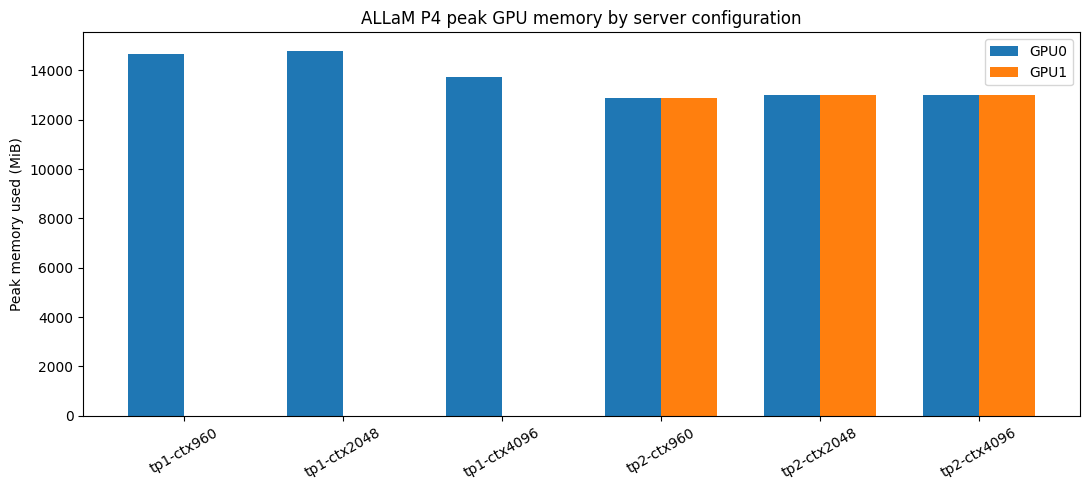

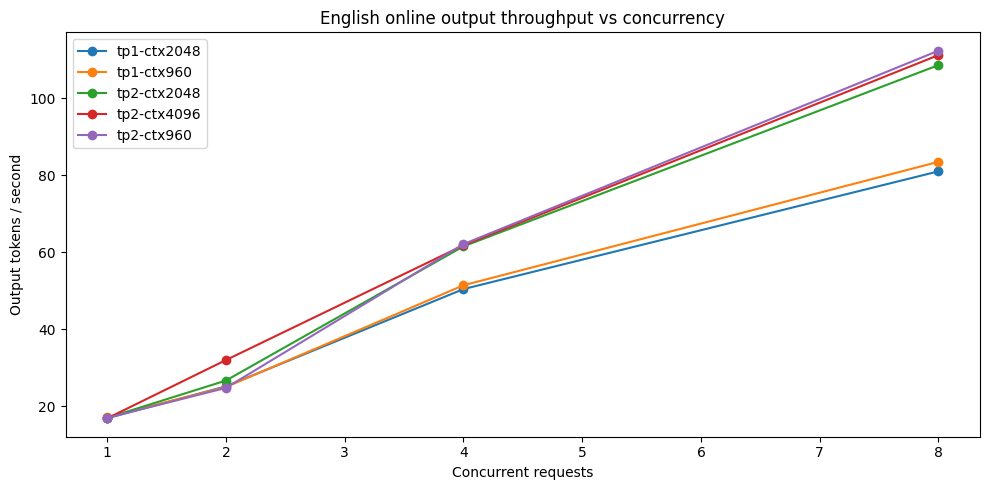

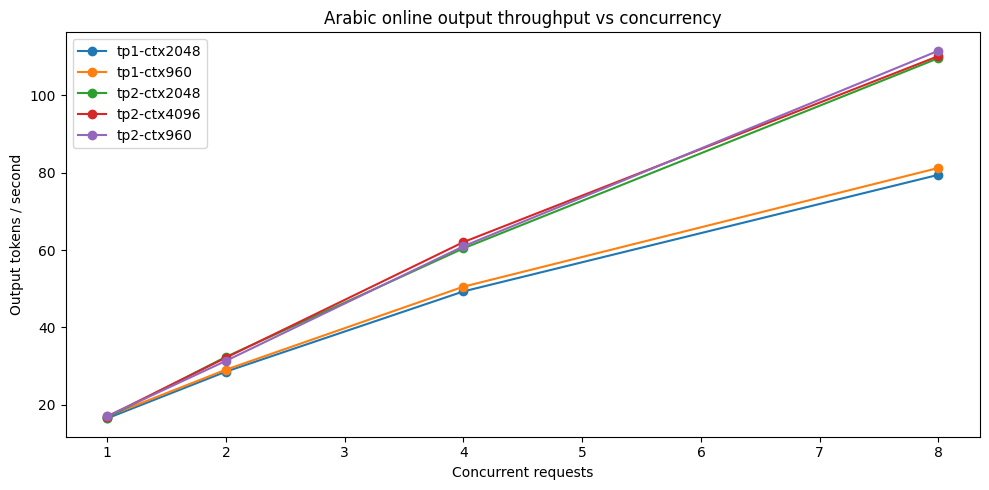

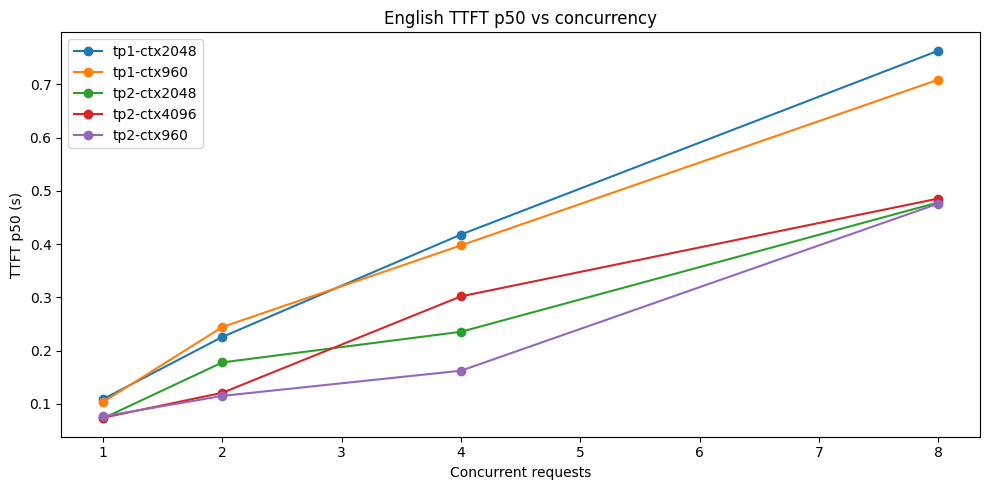

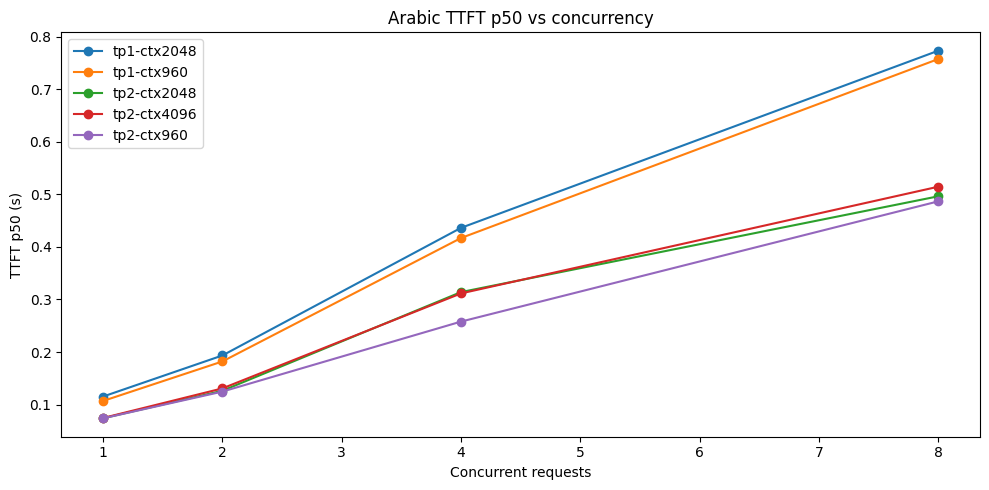

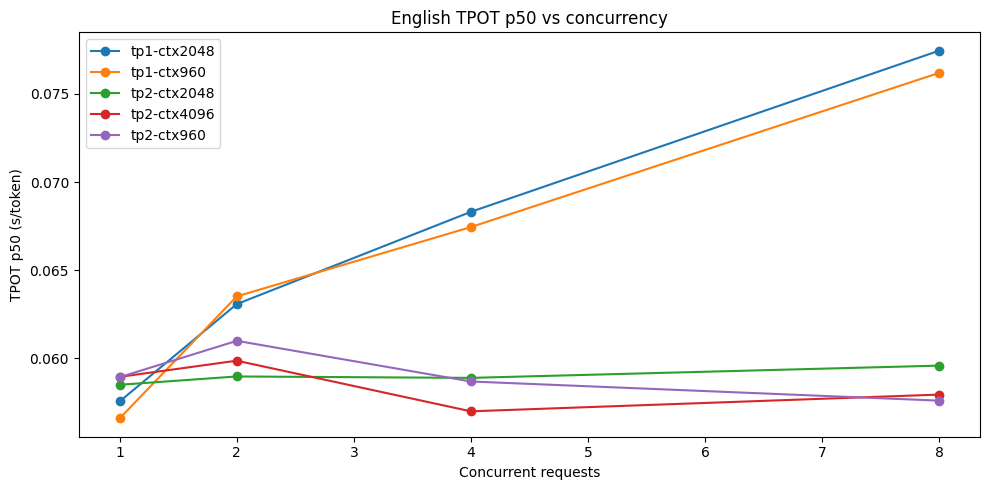

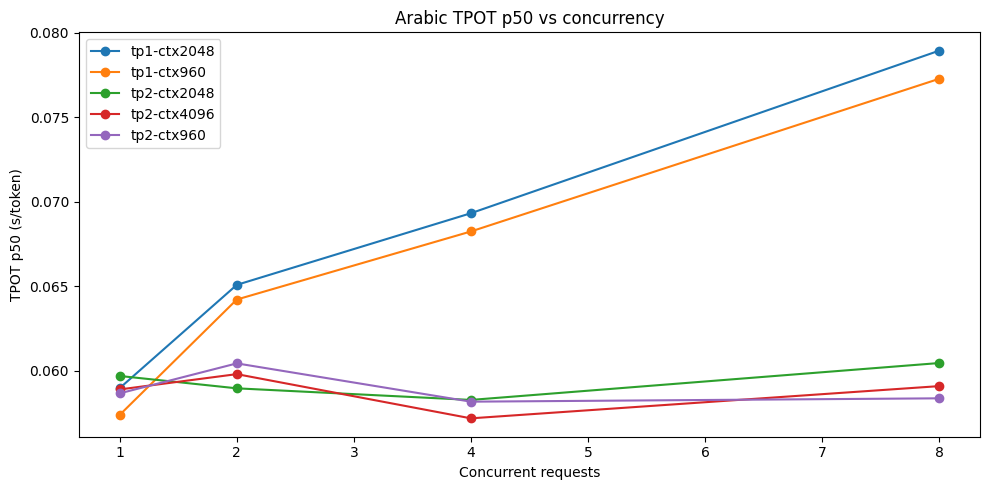

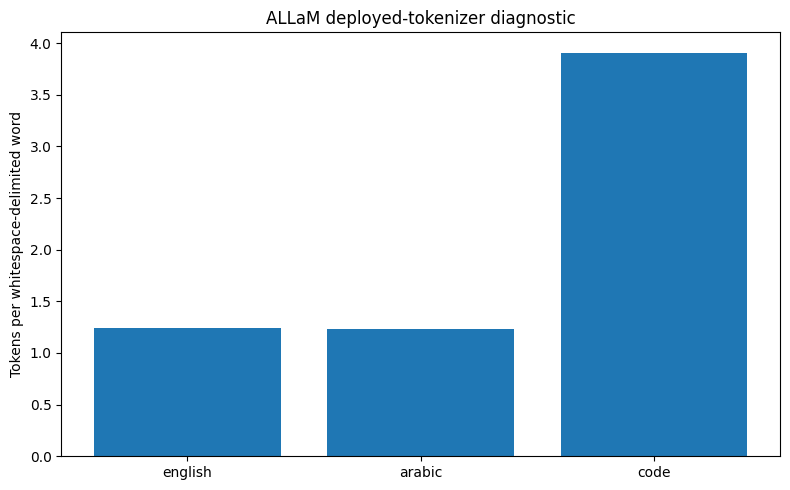

In [13]:
# ============================================================
# STEP 11 — Final plots
# ============================================================

import matplotlib.pyplot as plt

# 1. Peak GPU memory.
if len(config_df):
    fig, ax = plt.subplots(figsize=(11, 5))
    labels = config_df["tag"].tolist()
    x = list(range(len(labels)))
    width = 0.35

    g0 = config_df["gpu0_peak_mem_mib"].fillna(0)
    g1 = config_df["gpu1_peak_mem_mib"].fillna(0)

    ax.bar([i - width/2 for i in x], g0, width=width, label="GPU0")
    ax.bar([i + width/2 for i in x], g1, width=width, label="GPU1")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30)
    ax.set_ylabel("Peak memory used (MiB)")
    ax.set_title("ALLaM P4 peak GPU memory by server configuration")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "peak-gpu-memory.png", dpi=160)
    plt.show()

# Helper for one metric / one language.
def plot_metric(language, metric, ylabel, title, filename):
    if not len(wave_summary) or metric not in wave_summary.columns:
        return

    data = wave_summary[wave_summary["language"] == language]

    if not len(data):
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    for tag, group in data.groupby("tag"):
        group = group.sort_values("concurrency")
        ax.plot(
            group["concurrency"],
            group[metric],
            marker="o",
            label=tag,
        )

    ax.set_xlabel("Concurrent requests")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / filename, dpi=160)
    plt.show()

plot_metric(
    "english",
    "output_tps_mean",
    "Output tokens / second",
    "English online output throughput vs concurrency",
    "english-output-throughput.png",
)

plot_metric(
    "arabic",
    "output_tps_mean",
    "Output tokens / second",
    "Arabic online output throughput vs concurrency",
    "arabic-output-throughput.png",
)

# Latency curves use request-level aggregates.
def plot_latency(language, metric, ylabel, title, filename):
    if not len(request_summary) or metric not in request_summary.columns:
        return

    data = request_summary[request_summary["language"] == language]

    if not len(data):
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    for tag, group in data.groupby("tag"):
        group = group.sort_values("concurrency")
        ax.plot(
            group["concurrency"],
            group[metric],
            marker="o",
            label=tag,
        )

    ax.set_xlabel("Concurrent requests")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / filename, dpi=160)
    plt.show()

plot_latency(
    "english",
    "ttft_p50_s",
    "TTFT p50 (s)",
    "English TTFT p50 vs concurrency",
    "english-ttft-p50.png",
)

plot_latency(
    "arabic",
    "ttft_p50_s",
    "TTFT p50 (s)",
    "Arabic TTFT p50 vs concurrency",
    "arabic-ttft-p50.png",
)

plot_latency(
    "english",
    "tpot_p50_s",
    "TPOT p50 (s/token)",
    "English TPOT p50 vs concurrency",
    "english-tpot-p50.png",
)

plot_latency(
    "arabic",
    "tpot_p50_s",
    "TPOT p50 (s/token)",
    "Arabic TPOT p50 vs concurrency",
    "arabic-tpot-p50.png",
)

# Tokenizer diagnostic.
if len(fertility_df):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(
        fertility_df["sample"],
        fertility_df["tokens_per_word"],
    )
    ax.set_ylabel("Tokens per whitespace-delimited word")
    ax.set_title("ALLaM deployed-tokenizer diagnostic")
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "tokenizer-fertility.png", dpi=160)
    plt.show()

## 12. Final research summary table

This cell produces one compact table suitable for README/blog/paper drafting. It keeps measured facts separate from interpretation.

In [14]:
# ============================================================
# STEP 12 — Final summary tables
# ============================================================

summary_columns = [
    "tag",
    "status",
    "tp",
    "max_model_len",
    "gpu_memory_utilization",
    "server_startup_s",
    "model_loading_gib",
    "available_kv_cache_gib",
    "gpu_kv_cache_tokens",
    "estimated_max_model_len",
    "gpu0_peak_mem_mib",
    "gpu1_peak_mem_mib",
    "triton_attn_selected",
]

final_config_table = config_df[
    [c for c in summary_columns if c in config_df.columns]
].copy()

display(final_config_table)

if len(wave_summary):
    final_perf_table = wave_summary.merge(
        request_summary,
        on=["tag", "tp", "max_model_len", "language", "concurrency"],
        how="left",
    )

    display(final_perf_table)

    final_perf_table.to_csv(
        EVIDENCE_DIR / "final-performance-table.csv",
        index=False,
    )
else:
    final_perf_table = pd.DataFrame()

final_config_table.to_csv(
    EVIDENCE_DIR / "final-configuration-table.csv",
    index=False,
)

,tag,status,tp,max_model_len,gpu_memory_utilization,server_startup_s,model_loading_gib,available_kv_cache_gib,gpu_kv_cache_tokens,estimated_max_model_len,gpu0_peak_mem_mib,gpu1_peak_mem_mib,triton_attn_selected
0,tp1-ctx960,PASS,1,960,0.98,108.227233,13.04,1.00,2048.0,NaN,14671.0,0.0,True
1,tp1-ctx2048,PASS,1,2048,0.98,78.948905,13.04,1.00,2048.0,NaN,14799.0,0.0,True
2,tp1-ctx4096,RESOURCE_GATED,1,4096,0.98,64.120994,13.04,1.00,NaN,2048.0,13743.0,0.0,True
3,tp2-ctx960,PASS,2,960,0.85,91.231499,6.55,5.68,23248.0,NaN,12871.0,12871.0,True
4,tp2-ctx2048,PASS,2,2048,0.85,76.310712,6.55,5.68,23248.0,NaN,12997.0,12997.0,True
5,tp2-ctx4096,PASS,2,4096,0.85,76.283249,6.55,5.68,23248.0,NaN,13001.0,13001.0,True


,tag,tp,max_model_len,language,concurrency,waves,success_rate_mean,request_rps_mean,request_rps_median,output_tps_mean,...,ttft_p50_s,ttft_p95_s,ttft_p99_s,tpot_p50_s,tpot_p95_s,tpot_p99_s,e2e_p50_s,e2e_p95_s,e2e_p99_s,completion_tokens_mean
0,tp1-ctx2048,1,2048,arabic,1,3,1.0,0.514629,0.514553,16.468142,...,0.115173,0.115211,0.115214,0.058971,0.059133,0.059147,1.943265,1.948326,1.948776,32.0
1,tp1-ctx2048,1,2048,arabic,2,3,1.0,0.892190,0.891705,28.550089,...,0.193365,0.274995,0.275469,0.065080,0.066863,0.066873,2.212743,2.245375,2.246180,32.0
2,tp1-ctx2048,1,2048,arabic,4,3,1.0,1.540588,1.547974,49.298817,...,0.436418,0.471148,0.471391,0.069320,0.077390,0.077398,2.582365,2.622000,2.622260,32.0
3,tp1-ctx2048,1,2048,arabic,8,3,1.0,2.482975,2.485872,79.455202,...,0.773793,0.781928,0.782227,0.078940,0.097333,0.097609,3.216566,3.230539,3.230714,32.0
4,tp1-ctx2048,1,2048,english,1,3,1.0,0.527977,0.528327,16.895274,...,0.108858,0.109096,0.109117,0.057565,0.057690,0.057701,1.892595,1.897167,1.897573,32.0
5,tp1-ctx2048,1,2048,english,2,3,1.0,0.786754,0.904513,25.176144,...,0.225737,1.674300,1.857984,0.063081,0.084325,0.089231,2.182361,3.810255,3.815742,32.0
6,tp1-ctx2048,1,2048,english,4,3,1.0,1.575412,1.575090,50.413197,...,0.418074,0.428242,0.428379,0.068315,0.076146,0.076228,2.535833,2.543046,2.543197,32.0
7,tp1-ctx2048,1,2048,english,8,3,1.0,2.530185,2.524072,80.965914,...,0.763395,0.767831,0.768064,0.077454,0.095774,0.095880,3.167249,3.168900,3.169149,32.0
8,tp1-ctx960,1,960,arabic,1,3,1.0,0.529729,0.530340,16.951318,...,0.106757,0.109870,0.110147,0.057385,0.057497,0.057507,1.885429,1.892243,1.892848,32.0
9,tp1-ctx960,1,960,arabic,2,3,1.0,0.907996,0.909114,29.055883,...,0.181990,0.259857,0.261075,0.064211,0.065824,0.065864,2.175791,2.205652,2.207303,32.0


## 13. Evidence integrity

The final notebook hashes:

- strict doctor output
- server matrix JSON
- every server log
- every client log
- every online result JSON
- every GPU telemetry JSON
- all CSV summaries
- deterministic findings
- plots
- online benchmark client source
- tokenizer-fertility evidence

The raw logs and request-level records remain the source of truth; tables and plots are derived artifacts.

In [15]:
# ============================================================
# STEP 13 — Checksummed final evidence manifest
# ============================================================

def sha256_file(path, chunk_size=8 * 1024 * 1024):
    h = hashlib.sha256()

    with Path(path).open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)

    return h.hexdigest()


artifacts = sorted(
    p
    for p in RESEARCH_ROOT.rglob("*")
    if p.is_file()
    and p.name != "evidence-manifest.json"
)

artifact_rows = []

for path in artifacts:
    artifact_rows.append(
        {
            "path": str(path.relative_to(RESEARCH_ROOT)),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
    )

final_manifest = {
    "schema_version": 1,
    "project": "ALLaM-7B kaggle-vllm final characterization",
    "model_id": MODEL_ID,
    "model_commit": MODEL_COMMIT,
    "internal_version": EXPECTED_INTERNAL_VERSION,
    "sdk": f"kaggle-vllm=={SDK_VERSION}",
    "runtime_profile": runtime_manifest.get("profile"),
    "runtime_wheel": runtime_manifest.get("wheel"),
    "matrix": MATRIX,
    "languages": LANGUAGES,
    "concurrency_levels": CONCURRENCY_LEVELS,
    "repeats": REPEATS,
    "target_prompt_tokens": TARGET_PROMPT_TOKENS,
    "requested_output_tokens": OUTPUT_TOKENS,
    "artifacts": artifact_rows,
}

manifest_path = RESEARCH_ROOT / "evidence-manifest.json"

manifest_path.write_text(
    json.dumps(final_manifest, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

print("Evidence manifest:", manifest_path)
print("Artifacts hashed:", len(artifact_rows))
print("Final matrix statuses:")

for r in matrix_results:
    print(r["tag"], "->", r["status"])

Evidence manifest: /kaggle/working/allam-p4-final/evidence-manifest.json
Artifacts hashed: 46
Final matrix statuses:
tp1-ctx960 -> PASS
tp1-ctx2048 -> PASS
tp1-ctx4096 -> RESOURCE_GATED
tp2-ctx960 -> PASS
tp2-ctx2048 -> PASS
tp2-ctx4096 -> PASS


# Final interpretation guide

A successful P4 run supports **configuration-specific** claims such as:

- TP=1 at a measured context either passed or was resource-gated.
- TP=2 served a measured context through the real OpenAI-compatible vLLM server.
- A near-context streamed request completed at the measured prompt/output token counts.
- At concurrency `C`, English or Arabic produced a measured p50/p95/p99 TTFT/TPOT/E2E distribution across repeated waves.
- TP2-vs-TP1 percentage deltas at the matched 960-token context are measured, not assumed.
- `TRITON_ATTN`, KV-cache headroom, startup time, GPU memory, and NCCL facts come from the preserved server logs/telemetry.

Do **not** turn P4 into claims that:

- TP=2 is universally better than TP=1;
- T4 results represent A100 training performance;
- a small tokenizer diagnostic reproduces the ALLaM paper's corpus-level tokenizer study;
- streaming latency proves model quality;
- successful 4096 execution proves every possible 4096-token workload is stable;
- chat sanity reproduces MMLU, MT-Bench, human preference, safety, or cultural-alignment evaluation.

---

## Research-completion criterion

P4 is complete when:

1. the hardware and strict runtime gates pass;
2. all six configurations are classified;
3. every viable server completes the fixed-language repeated online benchmark;
4. near-context probes are recorded;
5. chat sanity is recorded;
6. request-level and aggregate TTFT/TPOT/E2E/throughput datasets exist;
7. final plots are generated;
8. the evidence manifest hashes every artifact.

At that point, further work should be treated as a **new research question**, not another repair of the ALLaM characterization notebook.

In [18]:
!zip -rq /kaggle/working/allam-p4-final.zip /kaggle/working/allam-p4-final